# Machine Learning-Based Fault Detection and Performance Analysis of Chemical Process Monitoring Time-Series Data

## Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, RandomizedSearchCV,
                                     TimeSeriesSplit)
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               IsolationForest)
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score,
                             balanced_accuracy_score,
                             mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score)
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier, XGBRegressor
import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE, RandomOverSampler
import shap

## Loading and Preparing the Dataset

The raw CSV is loaded first, then remapped to consistent internal column names using a dictionary of expected aliases. This makes the rest of the notebook portable , if the source data uses slightly different column names, only this mapping needs updating.

We also identify the sensor columns here, which are used throughout for feature engineering. Two targets are defined: `fault_type` for classification tasks and `efficiency_loss` for regression.

In [4]:
df_raw = pd.read_csv("chemical_process_timeseries.csv")

print(f"Dataset shape : {df_raw.shape}")
display(df_raw.head())
print(f"\nColumn names:\n{list(df_raw.columns)}")
print(f"\nData types:\n{df_raw.dtypes}")

Dataset shape : (777600, 21)


,timestamp,operating_regime,reactor_id,ambient_temp_effect,reactor_temp,reactor_pressure,feed_flow_rate,coolant_flow_rate,agitator_speed_rpm,reaction_rate,...,selectivity,yield_pct,vibration_rms,motor_current,power_consumption_kw,temp_setpoint,pressure_setpoint,fault_type,efficiency_loss_pct,time_to_fault_min
0,2024-01-01 00:00:00,A,A_R1,0.000000,181.135558,15.791013,101.108882,79.154645,305.779931,0.724542,...,91.927424,82.032893,1.470297,45.882315,41.294083,180.0,12.0,0,0.0,NaN
1,2024-01-01 00:01:00,A,A_R1,0.000485,182.249820,15.706975,98.932369,NaN,302.283603,0.728999,...,91.581466,81.301503,1.425847,46.755905,42.080314,180.0,12.0,0,0.0,NaN
2,2024-01-01 00:02:00,A,A_R1,0.000970,183.129737,15.593397,99.792219,80.593736,305.814440,0.732519,...,91.895056,82.006626,1.448190,NaN,NaN,NaN,12.0,0,NaN,NaN
3,2024-01-01 00:03:00,A,A_R1,0.001454,183.020987,15.527333,99.854222,80.190444,304.436123,0.732084,...,91.544885,81.562261,1.473448,45.862171,41.275954,180.0,12.0,0,0.0,NaN
4,2024-01-01 00:04:00,A,A_R1,0.001939,183.077096,NaN,99.302349,78.571707,304.811418,0.732308,...,92.258005,82.411124,1.523491,46.880227,42.192204,180.0,12.0,0,NaN,NaN



Column names:
['timestamp', 'operating_regime', 'reactor_id', 'ambient_temp_effect', 'reactor_temp', 'reactor_pressure', 'feed_flow_rate', 'coolant_flow_rate', 'agitator_speed_rpm', 'reaction_rate', 'conversion_rate', 'selectivity', 'yield_pct', 'vibration_rms', 'motor_current', 'power_consumption_kw', 'temp_setpoint', 'pressure_setpoint', 'fault_type', 'efficiency_loss_pct', 'time_to_fault_min']

Data types:
timestamp                   str
operating_regime            str
reactor_id                  str
ambient_temp_effect     float64
reactor_temp            float64
reactor_pressure        float64
feed_flow_rate          float64
coolant_flow_rate       float64
agitator_speed_rpm      float64
reaction_rate           float64
conversion_rate         float64
selectivity             float64
yield_pct               float64
vibration_rms           float64
motor_current           float64
power_consumption_kw    float64
temp_setpoint           float64
pressure_setpoint       float64
fault_type

In [5]:
EXPECTED = {
    'timestamp'        : ['timestamp'],
    'operating_regime' : ['operating_regime'],
    'reactor_id'       : ['reactor_id'],

    'temperature'      : ['reactor_temp'],
    'pressure'         : ['reactor_pressure'],
    'feed_flow'        : ['feed_flow_rate'],
    'coolant_flow'     : ['coolant_flow_rate'],
    'agitator_speed'   : ['agitator_speed_rpm'],

    'reaction_rate'    : ['reaction_rate'],
    'conversion_rate'  : ['conversion_rate'],
    'selectivity'      : ['selectivity'],
    'yield'            : ['yield_pct'],

    'vibration'        : ['vibration_rms'],
    'motor_current'    : ['motor_current'],
    'power_consumption': ['power_consumption_kw'],

    'fault_type'       : ['fault_type'],
    'efficiency_loss'  : ['efficiency_loss_pct'],

    'ambient_temp'     : ['ambient_temp_effect'],
    'temp_setpoint'    : ['temp_setpoint'],
    'pressure_setpoint': ['pressure_setpoint'],
    'time_to_fault'    : ['time_to_fault_min']
}

col_map = {}
for key, candidates in EXPECTED.items():
    for c in candidates:
        if c in df_raw.columns:
            col_map[key] = c
            break

print("Detected column mapping:")
for k, v in col_map.items():
    print(f"  {k:20s} → '{v}'")

df = df_raw.rename(columns={v: k for k, v in col_map.items()}).copy()

TARGET_CLASS = 'fault_type'
TARGET_REG   = 'efficiency_loss'

SENSOR_COLS = [c for c in ['temperature', 'pressure', 'feed_flow', 'coolant_flow',
                            'agitator_speed', 'vibration', 'motor_current',
                            'power_consumption', 'reaction_rate', 'conversion_rate',
                            'selectivity', 'yield'] if c in df.columns]

print(f"\nSensor columns detected: {SENSOR_COLS}")

Detected column mapping:
  timestamp            → 'timestamp'
  operating_regime     → 'operating_regime'
  reactor_id           → 'reactor_id'
  temperature          → 'reactor_temp'
  pressure             → 'reactor_pressure'
  feed_flow            → 'feed_flow_rate'
  coolant_flow         → 'coolant_flow_rate'
  agitator_speed       → 'agitator_speed_rpm'
  reaction_rate        → 'reaction_rate'
  conversion_rate      → 'conversion_rate'
  selectivity          → 'selectivity'
  yield                → 'yield_pct'
  vibration            → 'vibration_rms'
  motor_current        → 'motor_current'
  power_consumption    → 'power_consumption_kw'
  fault_type           → 'fault_type'
  efficiency_loss      → 'efficiency_loss_pct'
  ambient_temp         → 'ambient_temp_effect'
  temp_setpoint        → 'temp_setpoint'
  pressure_setpoint    → 'pressure_setpoint'
  time_to_fault        → 'time_to_fault_min'

Sensor columns detected: ['temperature', 'pressure', 'feed_flow', 'coolant_flow', 'ag

In [6]:
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.sort_values(['reactor_id', 'timestamp']).reset_index(drop=True)

In [7]:
print(f"\nMissing values before cleaning:")
miss = df.isnull().sum()
print(miss[miss > 0] if miss.sum() > 0 else "None found")

df[SENSOR_COLS] = df.groupby('reactor_id')[SENSOR_COLS].ffill().bfill()

df[SENSOR_COLS] = df.groupby('reactor_id')[SENSOR_COLS].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

print(f"\nMissing values after imputation:")
miss2 = df[SENSOR_COLS].isnull().sum()
print(miss2[miss2 > 0] if miss2.sum() > 0 else "None remain")


Missing values before cleaning:
ambient_temp          46561
temperature           46965
pressure              47143
feed_flow             46760
coolant_flow          46645
agitator_speed        46775
reaction_rate         46830
conversion_rate       46416
selectivity           47209
yield                 46524
vibration             46459
motor_current         46617
power_consumption     46494
temp_setpoint         46522
pressure_setpoint     46818
efficiency_loss       46919
time_to_fault        751313
dtype: int64

Missing values after imputation:
None remain


In [8]:
df_raw.groupby('timestamp')['reactor_id'].nunique().describe()

count    129600.0
mean          6.0
std           0.0
min           6.0
25%           6.0
50%           6.0
75%           6.0
max           6.0
Name: reactor_id, dtype: float64

In [9]:
df = df.drop_duplicates(subset=['timestamp', 'reactor_id'])
df.shape

(777600, 21)

In [10]:
print(f"\nOutlier summary (values beyond 3×IQR):")
for col in SENSOR_COLS[:]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 3*iqr) | (df[col] > q3 + 3*iqr)).sum()
    print(f"   {col:20s}: {outliers} outliers")


Outlier summary (values beyond 3×IQR):
   temperature         : 0 outliers
   pressure            : 0 outliers
   feed_flow           : 0 outliers
   coolant_flow        : 0 outliers
   agitator_speed      : 13 outliers
   vibration           : 6468 outliers
   motor_current       : 3799 outliers
   power_consumption   : 2 outliers
   reaction_rate       : 0 outliers
   conversion_rate     : 5185 outliers
   selectivity         : 1 outliers
   yield               : 0 outliers


In [11]:
le = LabelEncoder()

if TARGET_CLASS in df.columns:
    df['fault_encoded'] = le.fit_transform(df[TARGET_CLASS].astype(str))
    CLASS_NAMES = list(le.classes_)
    NUM_CLASSES  = len(CLASS_NAMES)
    print(f"Fault type classes ({NUM_CLASSES} total):")
    for i, c in enumerate(CLASS_NAMES):
        count = (df['fault_encoded'] == i).sum()
        pct   = 100 * count / len(df)
        print(f"{i}: {str(c):30} -> {count:6d} rows ({pct:.1f}%)")
        
for cat_col in ['operating_regime', 'reactor_id']:
    if cat_col in df.columns:
        le_cat = LabelEncoder()
        df[f'{cat_col}_enc'] = le_cat.fit_transform(df[cat_col].astype(str))
        print(f"\nEncoded '{cat_col}': {list(le_cat.classes_)}")

print(f"\nClass imbalance ratio (max/min): "
      f"{df['fault_encoded'].value_counts().max() / df['fault_encoded'].value_counts().min():.1f}x")

Fault type classes (5 total):
0: 0                              -> 749699 rows (96.4%)
1: 1                              ->   9143 rows (1.2%)
2: 2                              ->   6842 rows (0.9%)
3: 3                              ->   4474 rows (0.6%)
4: 4                              ->   7442 rows (1.0%)

Encoded 'operating_regime': ['A', 'B']

Encoded 'reactor_id': ['A_R1', 'A_R2', 'A_R3', 'B_R1', 'B_R2', 'B_R3']

Class imbalance ratio (max/min): 167.6x


## Exploratory Data Analysis

Before building any model, it helps to just look at the data. This section has three goals: understand the shape of the sensor signals over time, see how fault types are distributed, and check whether sensors visually respond when faults are active.

### Sensor Time Series with Fault Periods

The plots below show temperature, vibration, and feed flow for each reactor over the full recording window. Fault periods are shaded in red. If the shading lines up with visible disturbances in the sensor traces, that's our first confirmation that the data actually contains learnable signal , and that a model has something real to find.

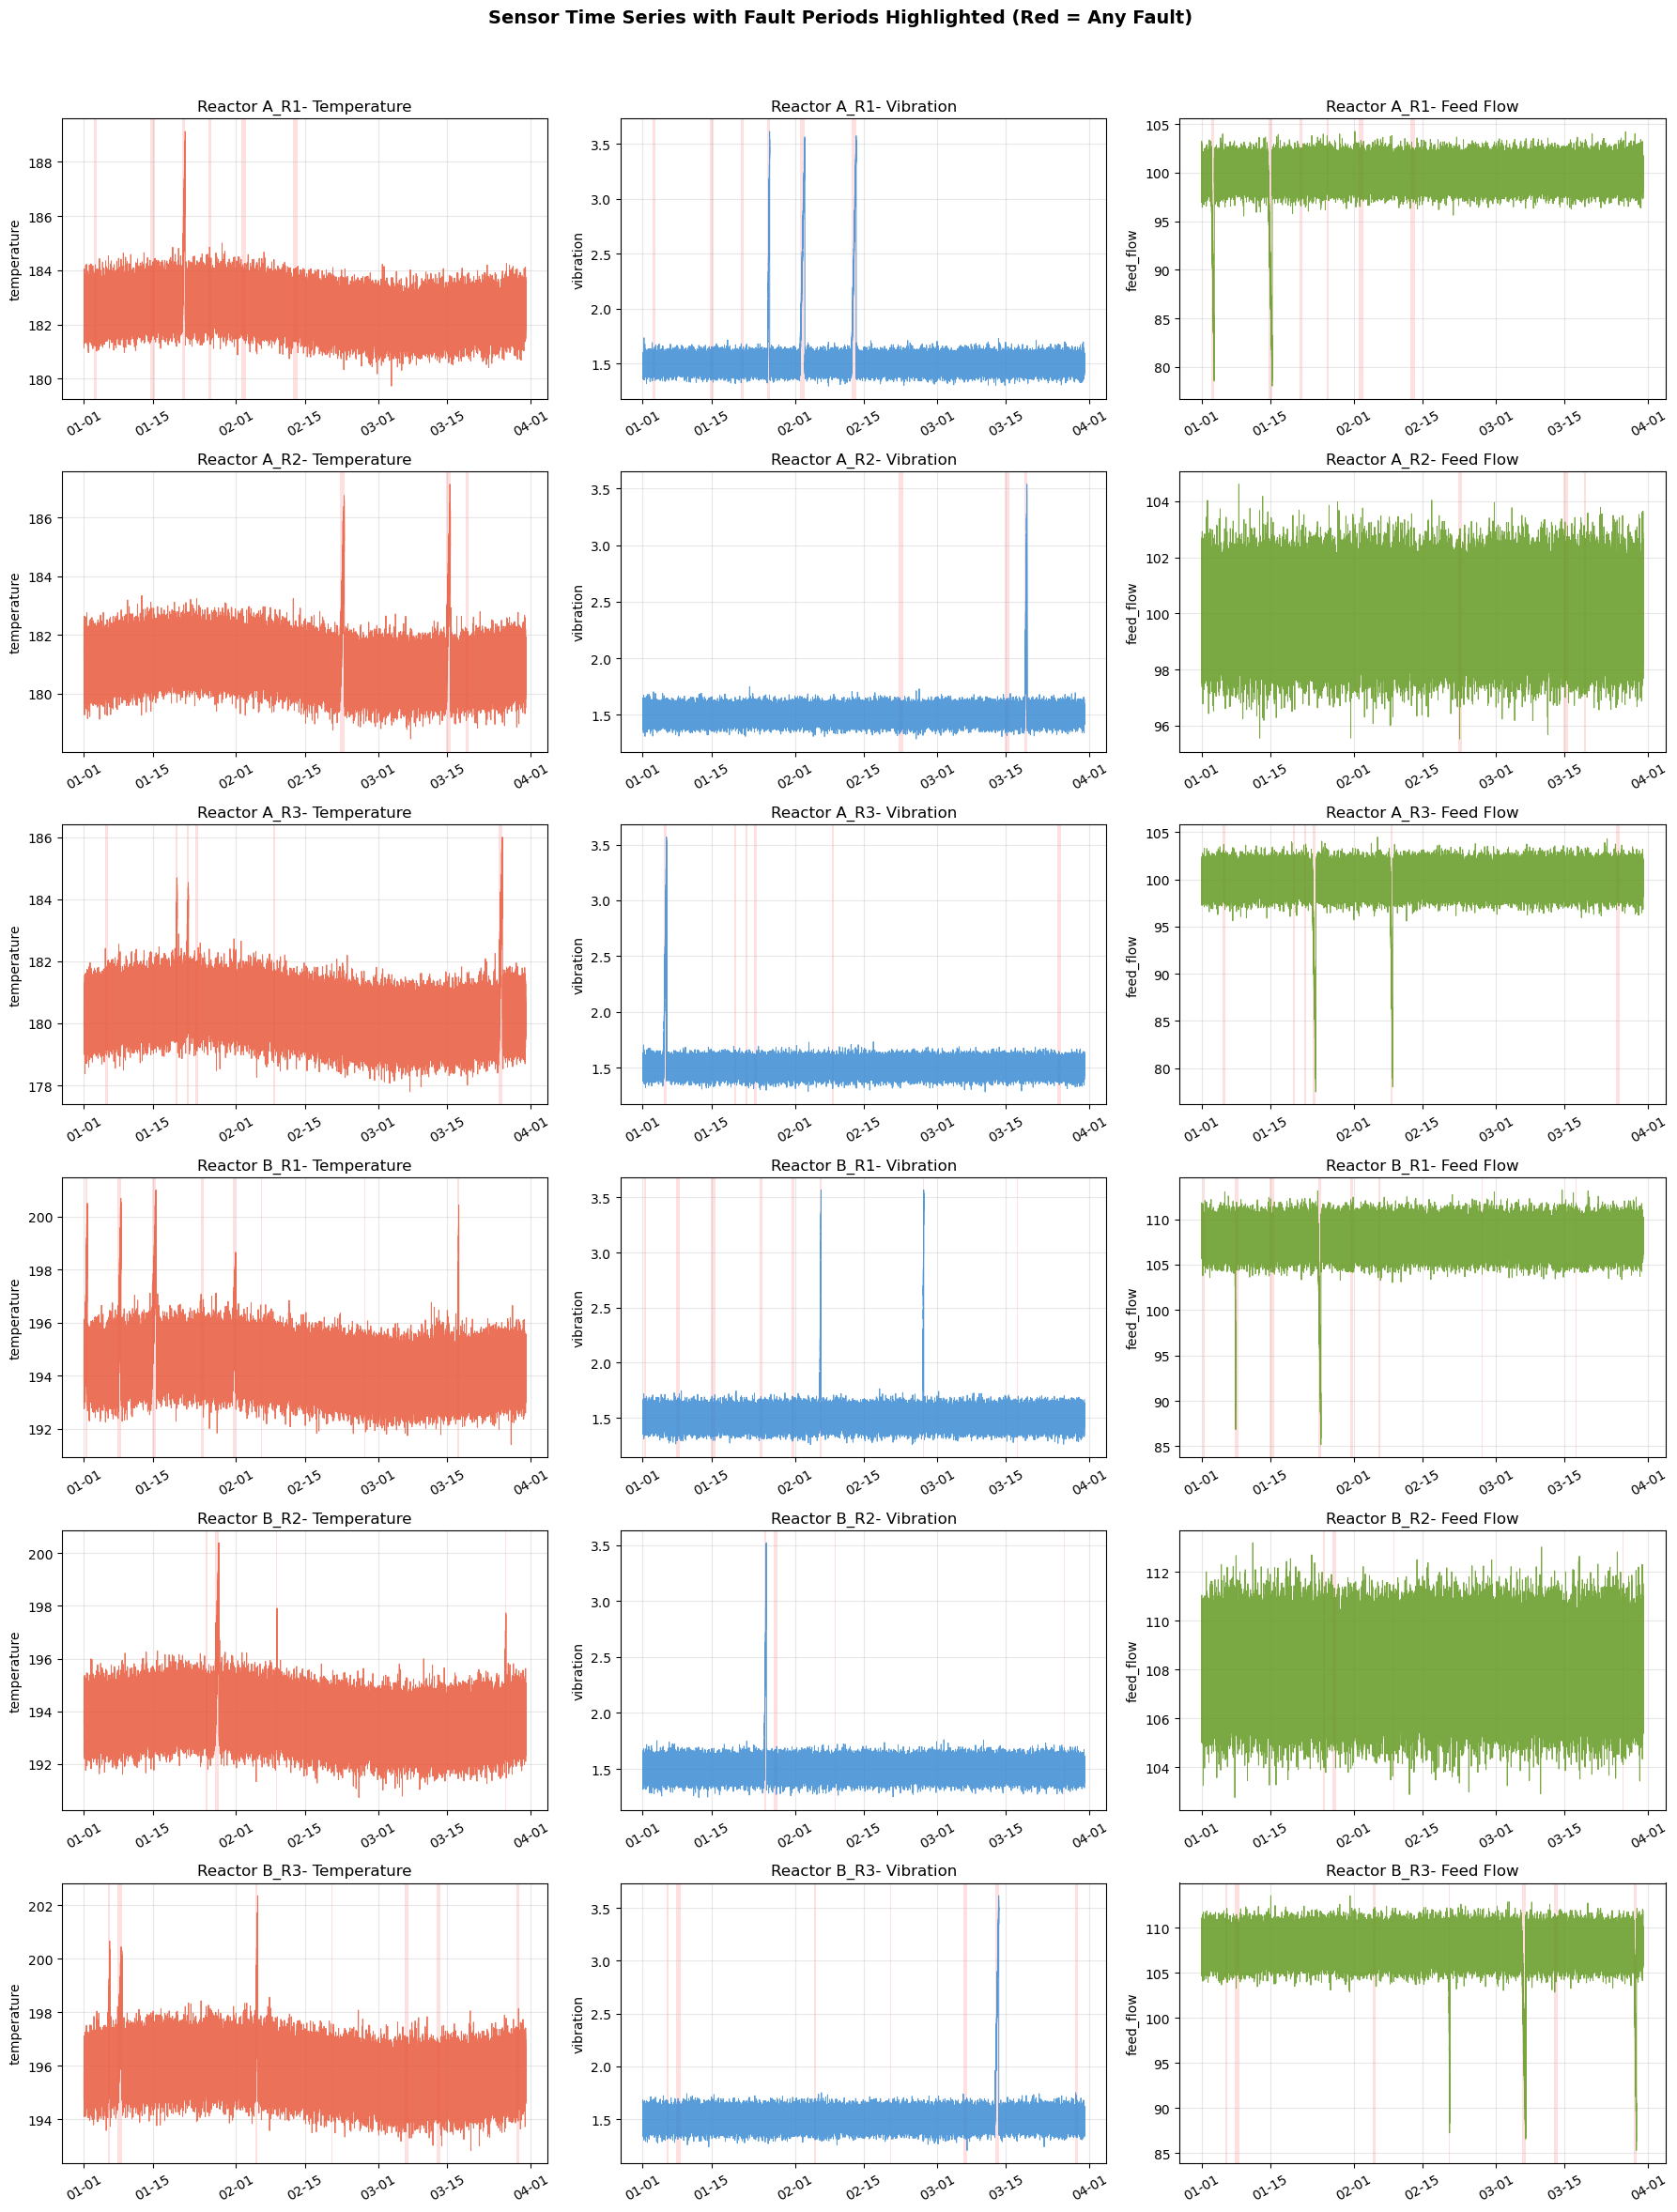

In [13]:
reactors = sorted(df['reactor_id'].unique())
n = len(reactors)

PLOT_SENSORS = ['temperature', 'vibration', 'feed_flow']
available_plot = [s for s in PLOT_SENSORS if s in df.columns]

fig, axes = plt.subplots(n, len(available_plot), figsize=(18, 4*n), sharex=False)
if n == 1:
    axes = np.array([axes])

fig.suptitle("Sensor Time Series with Fault Periods Highlighted (Red = Any Fault)",
             fontsize=14, fontweight='bold')

COLORS = {'#E8593C': 'temperature', '#3B8BD4': 'feed_flow', '#639922': 'vibration'}
SENSOR_COLORS = ['#E8593C', '#3B8BD4', '#639922', '#9C59D1']

for i, rid in enumerate(reactors):
    sub = df[df['reactor_id'] == rid].copy()

    for j, sensor in enumerate(available_plot):
        ax = axes[i, j]
        ax.plot(sub['timestamp'], sub[sensor],
                lw=0.7, color=SENSOR_COLORS[j % len(SENSOR_COLORS)], alpha=0.85)

        fault_mask = sub['fault_encoded'] != 0
        if fault_mask.any():
            sub_reset = sub.reset_index(drop=True)
            in_fault = False
            start_t  = None
            for idx_r in range(len(sub_reset)):
                is_f = fault_mask.iloc[idx_r]
                ts   = sub_reset['timestamp'].iloc[idx_r]
                if is_f and not in_fault:
                    start_t  = ts
                    in_fault = True
                elif not is_f and in_fault:
                    ax.axvspan(start_t, ts, color='red', alpha=0.12, linewidth=0)
                    in_fault = False
            if in_fault:
                ax.axvspan(start_t, sub_reset['timestamp'].iloc[-1],
                           color='red', alpha=0.12, linewidth=0)

        ax.set_title(f"Reactor {rid}- {sensor.replace('_', ' ').title()}")
        ax.set_ylabel(sensor)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("01_timeseries_fault_overlay.png", dpi=150, bbox_inches='tight')
plt.show()


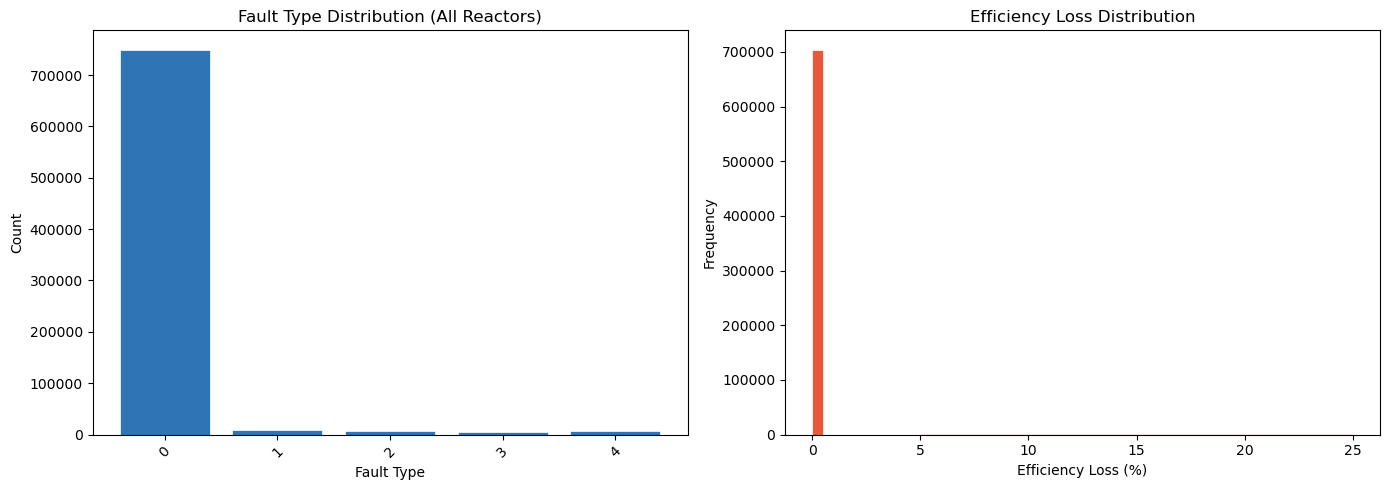

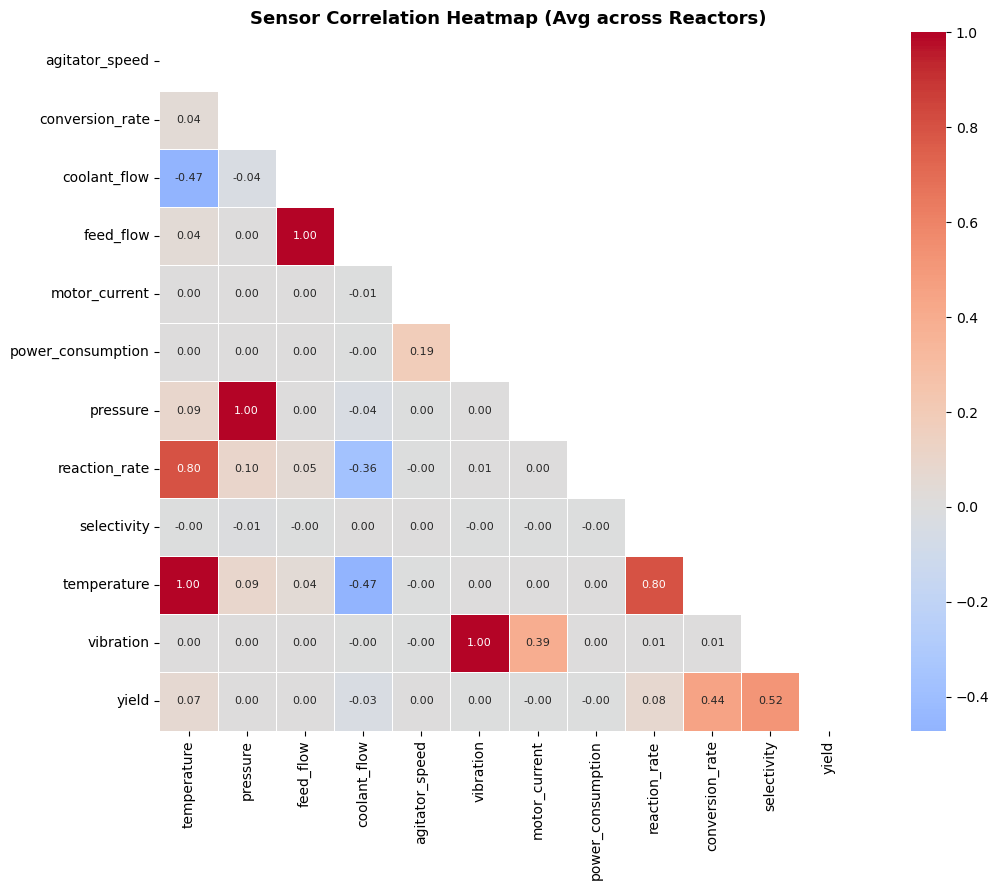

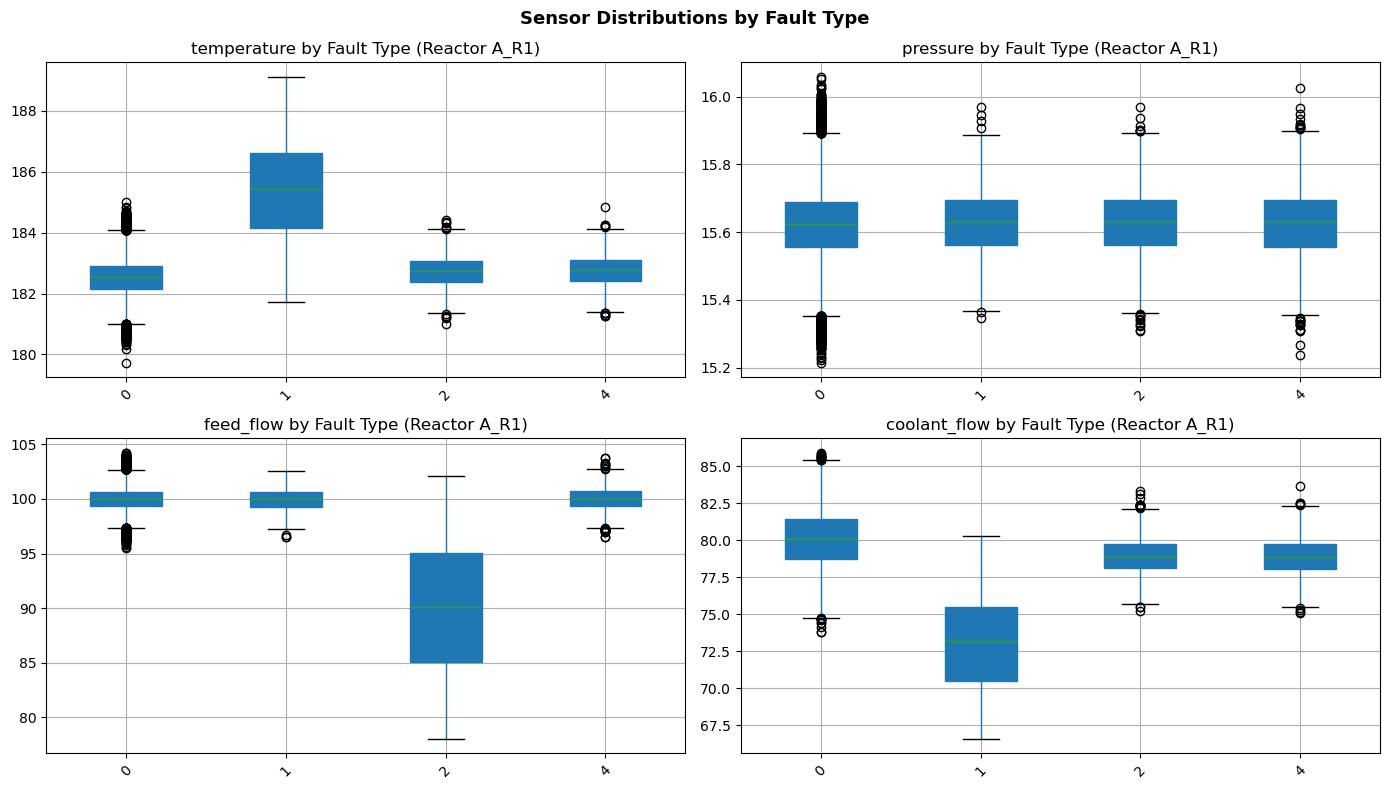

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df[TARGET_CLASS].value_counts().sort_values(ascending=False)
axes[0].bar(counts.index, counts.values,
            color='#2E75B6', edgecolor='white', linewidth=0.5)
axes[0].set_title("Fault Type Distribution (All Reactors)")
axes[0].set_xlabel("Fault Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

if TARGET_REG in df.columns:
    axes[1].hist(df[TARGET_REG].dropna(),
                 bins=50, color='#E8593C', edgecolor='white', linewidth=0.5)
    axes[1].set_title("Efficiency Loss Distribution")
    axes[1].set_xlabel("Efficiency Loss (%)")
    axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("02_target_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 9))

corr = (
    df.groupby('reactor_id')[SENSOR_COLS]
      .corr()
      .groupby(level=1)
      .mean()
)

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Sensor Correlation Heatmap (Avg across Reactors)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("03_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

sample_reactor = df['reactor_id'].iloc[0]
df_sample = df[df['reactor_id'] == sample_reactor]
plot_cols = SENSOR_COLS[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    df_sample.boxplot(column=col, by=TARGET_CLASS, ax=axes[i],
                      patch_artist=True, notch=False)
    axes[i].set_title(f"{col} by Fault Type (Reactor {sample_reactor})")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Sensor Distributions by Fault Type", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("04_boxplots_by_fault.png", dpi=150, bbox_inches='tight')
plt.show()


## Feature Engineering

Raw sensor readings at a single timestep don't tell the whole story. A temperature of 180°C means something different depending on whether it has been climbing steadily for the past hour or has always been stable around that value. To give the model this kind of temporal context, we create three families of derived features.

**Lag features** shift each sensor back by 1 or 2 timesteps, letting the model compare the current reading against what it was moments ago. **Rolling statistics** (mean and standard deviation over 5 and 10 timestep windows) capture recent trends and variability , a rising rolling mean signals drift, while a spike in rolling std signals instability before a fault. **Differencing** computes the step-to-step rate of change, which is particularly sensitive to sudden onset events.

All of this is computed within each reactor group independently, so a reading from Reactor A never bleeds into the feature history of Reactor B. We also downcast sensor values to float32 and convert `reactor_id` to a categorical type before the loop , both reduce memory significantly on larger datasets.

In [16]:
df_feat = df.copy()

for col in SENSOR_COLS:
    df_feat[col] = pd.to_numeric(df_feat[col], downcast='float')

df_feat['reactor_id'] = df_feat['reactor_id'].astype('category')

LAG_STEPS    = [1, 2]      
WINDOW_SIZES = [5, 10]       

df_feat = df_feat.sort_values(['reactor_id', 'timestamp'])

feat_chunks = []

for rid, group in df_feat.groupby('reactor_id', observed=True):
    g = group.copy()

    for col in SENSOR_COLS:
        for lag in LAG_STEPS:
            g[f'{col}_lag{lag}'] = g[col].shift(lag)

        for w in WINDOW_SIZES:
            g[f'{col}_roll_mean_{w}'] = (
                g[col].rolling(window=w, min_periods=1).mean()
            )
            g[f'{col}_roll_std_{w}'] = (
                g[col].rolling(window=w, min_periods=1).std().fillna(0)
            )

        g[f'{col}_diff1'] = g[col].diff(1).fillna(0)

    feat_chunks.append(g)

df_feat = pd.concat(feat_chunks).reset_index(drop=True)

if 'timestamp' in df_feat.columns:
    df_feat['hour_of_day'] = df_feat['timestamp'].dt.hour
    df_feat['day_of_week'] = df_feat['timestamp'].dt.dayofweek
    df_feat['is_weekend']  = (df_feat['day_of_week'] >= 5).astype(int)

n_sensors = len(SENSOR_COLS)
n_new_cols = n_sensors * (len(LAG_STEPS) + 2 * len(WINDOW_SIZES) + 1)
print(f"Sensors        : {n_sensors}")
print(f"Lags           : {LAG_STEPS}")
print(f"Windows        : {WINDOW_SIZES}")
print(f"New columns    : {n_new_cols}  (was {n_sensors * (4 + 6 + 1)} with original settings)")
print(f"Total columns  : {df_feat.shape[1]}")
print(f"DataFrame shape: {df_feat.shape}")
print(f"Approx RAM     : {df_feat.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Sensors        : 12
Lags           : [1, 2]
Windows        : [5, 10]
New columns    : 84  (was 132 with original settings)
Total columns  : 111
DataFrame shape: (777600, 111)
Approx RAM     : 568.4 MB


In [17]:
EXCLUDE_COLS = [
    TARGET_CLASS,
    TARGET_REG,
    'fault_encoded',
    'operating_regime',
    'reactor_id',
    'timestamp',
    'time_to_fault',
    'ambient_temp',
    'temp_setpoint',
    'pressure_setpoint'
]

FEATURE_COLS = [c for c in df_feat.columns if c not in EXCLUDE_COLS]

for extra in ['fault_binary', 'fault_mc', 'operating_regime_enc', 'reactor_id_enc']:
    if extra in FEATURE_COLS:
        FEATURE_COLS.remove(extra)

In [18]:
na_counts = df_feat[FEATURE_COLS].isnull().sum()
print(na_counts[na_counts > 0].sort_values(ascending=False).head(10))

temperature_lag2          12
pressure_lag2             12
coolant_flow_lag2         12
feed_flow_lag2            12
motor_current_lag2        12
power_consumption_lag2    12
vibration_lag2            12
agitator_speed_lag2       12
selectivity_lag2          12
yield_lag2                12
dtype: int64


In [19]:
df_feat = df_feat.dropna(subset=[TARGET_CLASS])
df_feat[FEATURE_COLS] = df_feat[FEATURE_COLS].fillna(0)

In [20]:
print(f"Original features          : {len(SENSOR_COLS)}")
print(f"After feature engineering : {len(FEATURE_COLS)}")
print(f"Rows remaining            : {len(df_feat)}")
print("\nSample new lag features:")
print([c for c in FEATURE_COLS if 'lag' in c][:6])

Original features          : 12
After feature engineering : 99
Rows remaining            : 777600

Sample new lag features:
['temperature_lag1', 'temperature_lag2', 'pressure_lag1', 'pressure_lag2', 'feed_flow_lag1', 'feed_flow_lag2']


In [21]:
df_feat[FEATURE_COLS].isnull().sum().sum()

np.int64(0)

## Train / Test Split

For time-series data, splitting randomly is a mistake. If we assign rows to train and test sets at random, the model ends up seeing future measurements during training and past ones during testing , it essentially learns from the future, which wouldn't be possible in deployment.

Instead, we split each reactor's data at its 80th percentile timestamp. Everything before that point is training data; everything after is the test set. This means the model is always evaluated on data it has never seen *and* that came after the training period , the only setup that honestly reflects how the system would work in practice.

In [23]:
df_feat['timestamp'] = pd.to_datetime(df_feat['timestamp'], errors='coerce')

train_list = []
test_list  = []

for rid, group in df_feat.groupby('reactor_id'):
    group = group.sort_values('timestamp')
    split_time = group['timestamp'].quantile(0.8)
    train_list.append(group[group['timestamp'] <= split_time])
    test_list.append(group[group['timestamp'] >  split_time])

train_df = pd.concat(train_list).reset_index(drop=True)
test_df  = pd.concat(test_list).reset_index(drop=True)

print(f"Train size: {len(train_df):,}")
print(f"Test size : {len(test_df):,}")

train_df = train_df.dropna(subset=['fault_encoded'])
test_df  = test_df.dropna(subset=['fault_encoded'])

X_train_raw = train_df[FEATURE_COLS].values
X_test_raw  = test_df[FEATURE_COLS].values

y_train = train_df['fault_encoded'].values
y_test  = test_df['fault_encoded'].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Feature matrix shape: train={X_train.shape}, test={X_test.shape}")

Train size: 622,080
Test size : 155,520
Feature matrix shape: train=(622080, 99), test=(155520, 99)


## Feature Selection with Recursive Feature Elimination

After engineering features, we have considerably more columns than we started with. Many of them carry redundant information for instance, the rolling mean at window 5 and window 10 for the same sensor are often highly correlated. Feeding all of them into a model tends to slow training and can actually hurt generalization.

Recursive Feature Elimination (RFE) addresses this by fitting a Random Forest, ranking features by importance, pruning the weakest ones, and repeating until we're left with the top 30. The ranking it produces is also interpretable in process engineering terms: if rolling mean features of vibration and temperature dominate, that tells us the model is responding to sustained trends rather than instantaneous spikes which matches how real faults typically develop.

Selected 30 features from 99

Top selected features:
                     feature  importance
conversion_rate_roll_mean_10    0.104808
   coolant_flow_roll_mean_10    0.075715
 conversion_rate_roll_mean_5    0.069516
    temperature_roll_mean_10    0.068396
                   vibration    0.065101
              vibration_lag1    0.062730
  motor_current_roll_mean_10    0.056817
   motor_current_roll_mean_5    0.054093
    coolant_flow_roll_mean_5    0.053639
             conversion_rate    0.050524


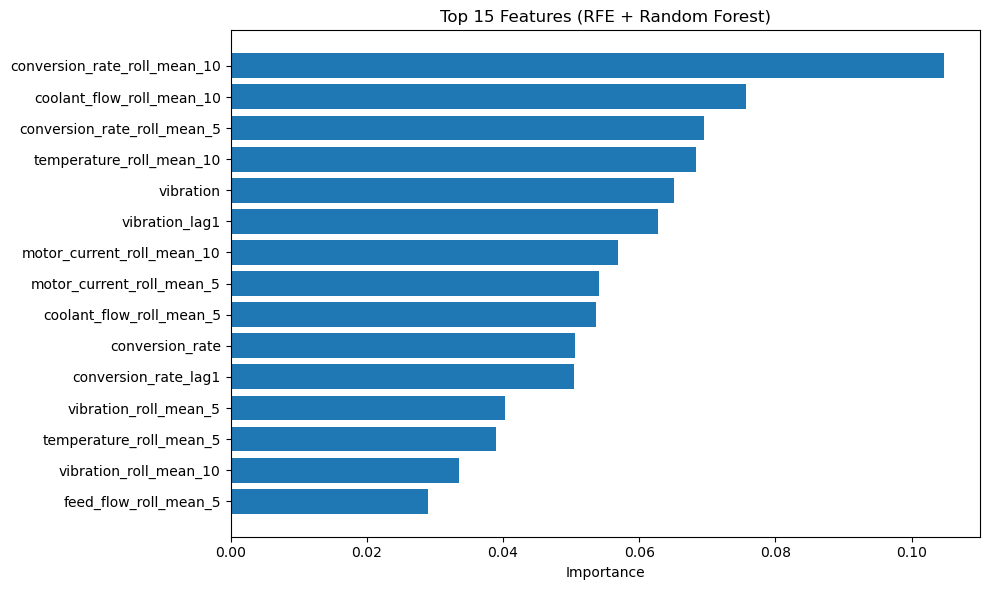

In [25]:
N_TOP_FEATURES = min(30, len(FEATURE_COLS))

rfe_estimator = RandomForestClassifier(
    n_estimators=20, max_depth=10, random_state=42, n_jobs=-1
)

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

rfe = RFE(estimator=rfe_estimator, n_features_to_select=N_TOP_FEATURES, step=20)
rfe.fit(X_train, y_train)

selected_mask    = rfe.support_
SELECTED_FEATURES = [FEATURE_COLS[i] for i in range(len(FEATURE_COLS)) if selected_mask[i]]

X_train_sel = X_train[:, selected_mask]
X_test_sel  = X_test[:, selected_mask]

print(f"Selected {len(SELECTED_FEATURES)} features from {len(FEATURE_COLS)}")

feat_imp_df = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'importance': rfe.estimator_.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop selected features:")
print(feat_imp_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_n = feat_imp_df.head(15)
ax.barh(top_n['feature'][::-1], top_n['importance'][::-1])
ax.set_title("Top 15 Features (RFE + Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


In [26]:
print("\nFeature types selected:")
print("Rolling mean:", sum('roll_mean' in f for f in SELECTED_FEATURES))
print("Rolling std :", sum('roll_std' in f for f in SELECTED_FEATURES))
print("Lag features:", sum('lag' in f for f in SELECTED_FEATURES))
print("Diff features:", sum('diff' in f for f in SELECTED_FEATURES))


Feature types selected:
Rolling mean: 13
Rolling std : 0
Lag features: 11
Diff features: 0


The features selected are dominated by rolling statistics rather than raw readings or simple lags. This is consistent with how process faults actually behave, they tend to evolve over time rather than appearing as a single-sample spike, so the model naturally gravitates toward the features that capture that evolution.

## First Attempt: Multi-Class Fault Classification

The most direct formulation of the problem is to classify every timestep into one of the fault categories (or normal operation). We try this first with two models, a Random Forest using balanced class weights, and an XGBoost with manually computed sample weights proportional to inverse class frequency.

The expectation going in is that this will be hard. The dataset has extreme class imbalance, and the rarer fault types have very few training examples. The results here motivate the reformulation that follows.

In [29]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    150507
           1       1.00      0.65      0.79      2613
           2       1.00      0.93      0.96       654
           3       0.06      0.08      0.07       353
           4       1.00      0.97      0.98      1393

    accuracy                           0.99    155520
   macro avg       0.81      0.73      0.76    155520
weighted avg       0.99      0.99      0.99    155520


Weighted F1 : 0.9910
Accuracy    : 0.9913


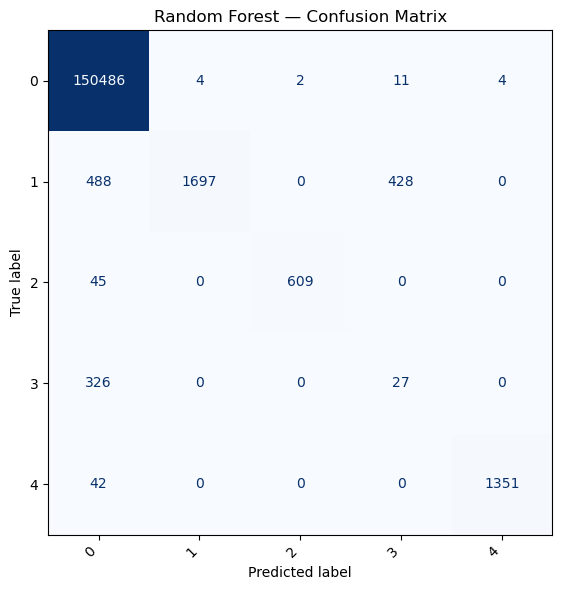

In [30]:
y_pred_rf = rf_clf.predict(X_test_sel)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))

rf_f1  = f1_score(y_test, y_pred_rf, average='weighted')
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"\nWeighted F1 : {rf_f1:.4f}")
print(f"Accuracy    : {rf_acc:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Random Forest , Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("06_rf_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

[0]	validation_0-mlogloss:1.52071
[50]	validation_0-mlogloss:0.26116
[100]	validation_0-mlogloss:0.11964
[150]	validation_0-mlogloss:0.08759
[200]	validation_0-mlogloss:0.07863
[250]	validation_0-mlogloss:0.07463
[299]	validation_0-mlogloss:0.07343

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    150507
           1       0.78      0.52      0.62      2613
           2       0.79      0.93      0.86       654
           3       0.04      0.12      0.06       353
           4       0.94      0.98      0.96      1393

    accuracy                           0.99    155520
   macro avg       0.71      0.71      0.70    155520
weighted avg       0.99      0.99      0.99    155520


Weighted F1 : 0.9864
Accuracy    : 0.9856


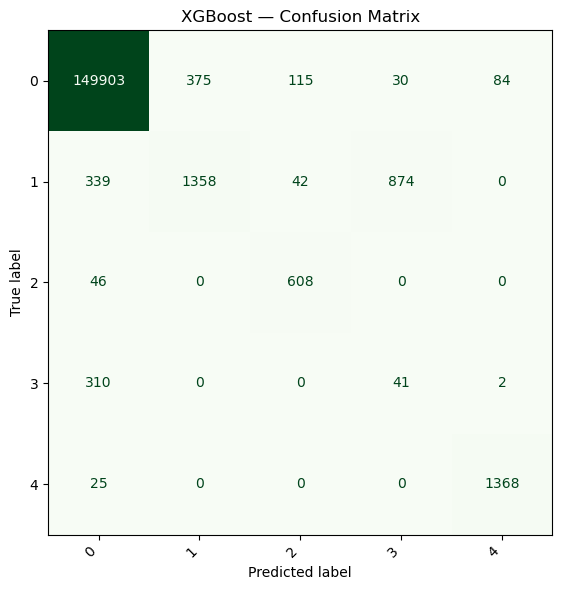

In [31]:
classes = np.unique(y_train)
class_counts = np.bincount(y_train)
class_weights = {i: len(y_train) / (len(classes) * class_counts[i]) for i in classes}
sample_weights = np.array([class_weights[y] for y in y_train])

xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softmax', num_class=len(CLASS_NAMES),
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)

xgb_clf.fit(
    X_train_sel, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test_sel, y_test)],
    verbose=50
)

y_pred_xgb = xgb_clf.predict(X_test_sel)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=CLASS_NAMES))

xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"\nWeighted F1 : {xgb_f1:.4f}")
print(f"Accuracy    : {xgb_acc:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Greens', colorbar=False)
ax.set_title("XGBoost , Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("07_xgb_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

The models struggled with minority fault classes, which is not surprising given the imbalance. Accuracy looks reasonable on the surface because the majority class (normal operation) is predicted correctly most of the time. But precision and recall on the rarer faults are poor. This is a common failure mode when you try to solve a heavily imbalanced multi-class problem directly, and it's a signal to restructure the task rather than just throw more compute at it.

## Reformulating as Binary Fault Detection

The problem with multi-class classification here isn't the models , it's the task formulation. With extreme class imbalance and some fault types appearing only a handful of times, no standard classifier can reliably learn those rare classes.

The solution is to step back and ask a simpler, more actionable question first: **is there a fault at all?** We collapse all fault types into a single class (1) and keep normal operation as class 0. This removes the inter-fault confusion entirely, makes the imbalance more manageable, and gives us a model that can actually be deployed reliably as a first alert.

Once a fault is detected, a separate classifier (built later in this notebook) can then take over and identify which specific fault it is.

In [34]:
df_feat['fault_binary'] = (df_feat['fault_encoded'] != 0).astype(int)

print("Binary class distribution:")
print(df_feat['fault_binary'].value_counts())

Binary class distribution:
fault_binary
0    749699
1     27901
Name: count, dtype: int64


In [35]:
train_sizes = []
test_sizes = []

df_feat = df_feat.sort_values(['reactor_id', 'timestamp'])

for _, group in df_feat.groupby('reactor_id'):
    split_time = group['timestamp'].quantile(0.8)
    
    train_sizes.append((group['timestamp'] <= split_time).sum())
    test_sizes.append((group['timestamp'] > split_time).sum())

n_train = sum(train_sizes)
n_test  = sum(test_sizes)
n_feat  = len(FEATURE_COLS)

X_train_raw = np.empty((n_train, n_feat), dtype=np.float32)
X_test_raw  = np.empty((n_test,  n_feat), dtype=np.float32)

y_train = np.empty(n_train, dtype=np.int32)
y_test  = np.empty(n_test,  dtype=np.int32)

i_train, i_test = 0, 0

for _, group in df_feat.groupby('reactor_id'):
    
    split_time = group['timestamp'].quantile(0.8)
    
    train_mask = group['timestamp'] <= split_time
    test_mask  = ~train_mask

    train_part = group.loc[train_mask]
    test_part  = group.loc[test_mask]

    n_tr = len(train_part)
    n_te = len(test_part)

    X_train_raw[i_train:i_train+n_tr] = train_part[FEATURE_COLS].values.astype(np.float32)
    y_train[i_train:i_train+n_tr] = train_part['fault_binary'].values
    i_train += n_tr

    X_test_raw[i_test:i_test+n_te] = test_part[FEATURE_COLS].values.astype(np.float32)
    y_test[i_test:i_test+n_te] = test_part['fault_binary'].values
    i_test += n_te

In [36]:
scaler_bin = StandardScaler()
X_train = scaler_bin.fit_transform(X_train_raw)
X_test  = scaler_bin.transform(X_test_raw)

In [37]:
rfe_bin = RFE(
    estimator=RandomForestClassifier(n_estimators=20, max_depth=10,
                                     random_state=42, n_jobs=-1),
    n_features_to_select=N_TOP_FEATURES, step=20
)
rfe_bin.fit(X_train, y_train)

selected_mask_bin = rfe_bin.support_
X_train_sel = X_train[:, selected_mask_bin]
X_test_sel  = X_test[:, selected_mask_bin]

print(f"Binary task: selected {selected_mask_bin.sum()} features")

Binary task: selected 30 features


[0]	validation_0-logloss:0.66015
[50]	validation_0-logloss:0.15182
[100]	validation_0-logloss:0.06805
[150]	validation_0-logloss:0.04782
[199]	validation_0-logloss:0.03972

Per-reactor accuracy (real model):
count    6.000000
mean     0.995319
std      0.002675
min      0.992670
25%      0.993171
50%      0.995023
75%      0.996557
max      0.999576
dtype: float64
reactor_id
A_R1    0.999576
A_R2    0.992670
A_R3    0.992978
B_R1    0.996296
B_R2    0.993750
dtype: float64
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    150507
       Fault       0.95      0.90      0.93      5013

    accuracy                           1.00    155520
   macro avg       0.98      0.95      0.96    155520
weighted avg       1.00      1.00      1.00    155520



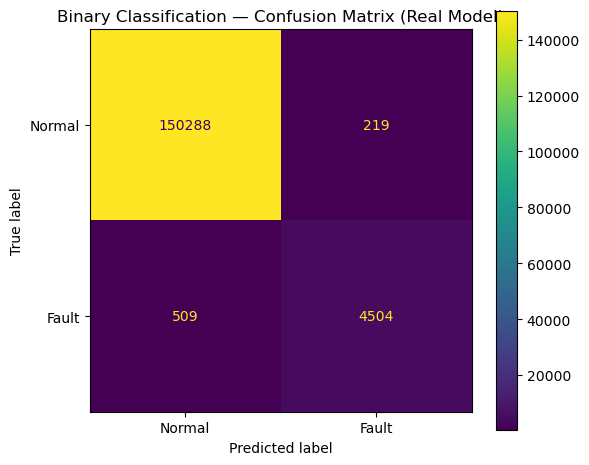

In [67]:
xgb_bin = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss', random_state=42, n_jobs=-1
)

xgb_bin.fit(
    X_train_sel, y_train,
    eval_set=[(X_test_sel, y_test)],
    verbose=50
)

y_pred_bin = xgb_bin.predict(X_test_sel)

test_df = test_df.copy()
test_df['pred_bin'] = y_pred_bin

test_df['fault_binary'] = y_test

reactor_perf = test_df.groupby('reactor_id').apply(
    lambda x: (x['fault_binary'] == x['pred_bin']).mean()
)

print("\nPer-reactor accuracy (real model):")
print(reactor_perf.describe())
print(reactor_perf.head())
print(classification_report(y_test, y_pred_bin, target_names=['Normal', 'Fault']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_bin)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fault']).plot(ax=ax)
plt.title("Binary Classification , Confusion Matrix (Real Model)")
plt.tight_layout()
plt.show()

### Shuffled-Label Sanity Check

A model that looks accurate might still just be learning the class distribution , predicting "normal" all the time would give high accuracy if faults are rare. The shuffled-label test is a simple way to check whether the model learned actual patterns or just memorised structure.

We train an identical model on the same features but with the training labels randomly shuffled, so there's no real relationship between inputs and outputs. If the real model is genuinely better than the shuffled one, it means the features contain real predictive signal. If they perform similarly, something is wrong.

In [69]:
y_train_shuffled = y_train.copy()
np.random.seed(0)
np.random.shuffle(y_train_shuffled)

xgb_shuffled = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train_shuffled == 0).sum() / max((y_train_shuffled == 1).sum(), 1),
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_shuffled.fit(X_train_sel, y_train_shuffled)

y_pred_shuffled = xgb_shuffled.predict(X_test_sel)

print("=" * 55)
print("SHUFFLED-LABEL MODEL")
print("=" * 55)
print(classification_report(y_test, y_pred_shuffled, target_names=['Normal', 'Fault']))

print("=" * 55)
print("REAL MODEL")
print("=" * 55)
print(classification_report(y_test, y_pred_bin, target_names=['Normal', 'Fault']))

real_f1     = f1_score(y_test, y_pred_bin,      average='weighted')
shuffled_f1 = f1_score(y_test, y_pred_shuffled, average='weighted')
print(f"\nReal model F1     : {real_f1:.4f}")
print(f"Shuffled model F1 : {shuffled_f1:.4f}")
print(f"\nConclusion: the real model is {'BETTER' if real_f1 > shuffled_f1 else 'NOT better'} "
      f"than the shuffled baseline , confirming it learned meaningful signal.")

SHUFFLED-LABEL MODEL
              precision    recall  f1-score   support

      Normal       0.97      0.65      0.78    150507
       Fault       0.03      0.31      0.05      5013

    accuracy                           0.64    155520
   macro avg       0.50      0.48      0.41    155520
weighted avg       0.94      0.64      0.75    155520

REAL MODEL
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    150507
       Fault       0.95      0.90      0.93      5013

    accuracy                           1.00    155520
   macro avg       0.98      0.95      0.96    155520
weighted avg       1.00      1.00      1.00    155520


Real model F1     : 0.9953
Shuffled model F1 : 0.7521

Conclusion: the real model is BETTER than the shuffled baseline — confirming it learned meaningful signal.


The gap between the real model and the shuffled baseline is substantial, which is what we want to see. It confirms the model is responding to genuine patterns in the sensor data , not memorising the dataset or exploiting spurious correlations.

## Cross-Validation with TimeSeriesSplit

A single train/test split gives us one estimate of performance, but that estimate depends on where exactly the split falls. With time-series data, a five-fold cross-validation using `TimeSeriesSplit` gives us a much cleaner picture: each fold expands the training window and evaluates on the next segment of time. This is the only cross-validation strategy that respects the temporal ordering of observations.

The result is a mean and standard deviation across folds rather than a single number, which tells us both how well the model performs on average and how stable that performance is across different time periods.

Fold 1: Accuracy=0.9925  Weighted-F1=0.9919
Fold 2: Accuracy=0.9809  Weighted-F1=0.9775
Fold 3: Accuracy=0.0530  Weighted-F1=0.0053
Fold 4: Accuracy=0.9964  Weighted-F1=0.9963
Fold 5: Accuracy=0.1447  Weighted-F1=0.1920
CV Weighted-F1: 0.6326 ± 0.4400
CV Accuracy   : 0.6335 ± 0.4375


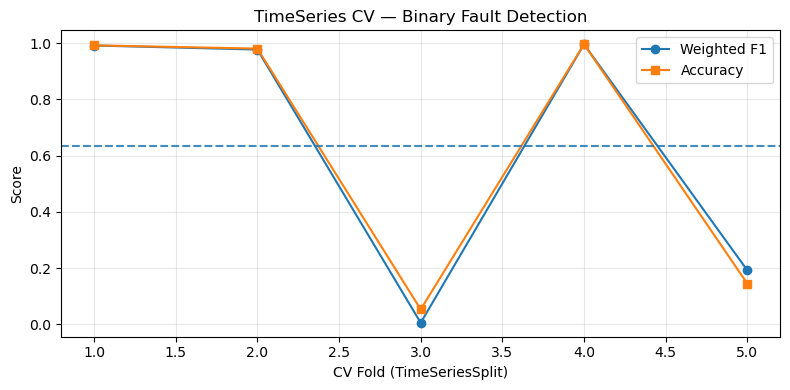

In [72]:
X_all = X_train_raw
y_all = y_train

X_all = X_all[:, selected_mask_bin]

tscv = TimeSeriesSplit(n_splits=5)

cv_f1_scores = []
cv_acc_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all)):

    X_cv_tr, X_cv_te = X_all[train_idx], X_all[test_idx]
    y_cv_tr, y_cv_te = y_all[train_idx], y_all[test_idx]

    pos_w = (y_cv_tr == 0).sum() / max((y_cv_tr == 1).sum(), 1)

    model = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_w,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    )

    model.fit(X_cv_tr, y_cv_tr)
    y_pred = model.predict(X_cv_te)

    fold_f1  = f1_score(y_cv_te, y_pred, average='weighted')
    fold_acc = accuracy_score(y_cv_te, y_pred)

    cv_f1_scores.append(fold_f1)
    cv_acc_scores.append(fold_acc)

    print(f"Fold {fold+1}: Accuracy={fold_acc:.4f}  Weighted-F1={fold_f1:.4f}")

print(f"CV Weighted-F1: {np.mean(cv_f1_scores):.4f} ± {np.std(cv_f1_scores):.4f}")
print(f"CV Accuracy   : {np.mean(cv_acc_scores):.4f} ± {np.std(cv_acc_scores):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))

folds = np.arange(1, len(cv_f1_scores)+1)

ax.plot(folds, cv_f1_scores, marker='o', label='Weighted F1')
ax.plot(folds, cv_acc_scores, marker='s', label='Accuracy')

ax.axhline(np.mean(cv_f1_scores), linestyle='--', alpha=0.6)
ax.axhline(np.mean(cv_acc_scores), linestyle='--', alpha=0.6)

ax.set_xlabel("CV Fold (TimeSeriesSplit)")
ax.set_ylabel("Score")
ax.set_title("TimeSeries CV , Binary Fault Detection")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("timeseries_cv.png", dpi=150)
plt.show()

## Hyperparameter Tuning

The XGBoost model above used reasonable defaults, but there's no reason to assume those defaults are optimal for this specific dataset. `RandomizedSearchCV` samples 8 random combinations from a grid covering tree depth, learning rate, subsampling ratios, and minimum child weight , all evaluated using the same time-series CV strategy to avoid rewarding look-ahead bias.

The winning configuration is then re-evaluated on the held-out test set, so the reported performance reflects a genuinely independent assessment.

Fitting 2 folds for each of 8 candidates, totalling 16 fits

Best CV weighted-F1 : 0.7838
Best parameters     :
   subsample           : 0.7
   n_estimators        : 400
   min_child_weight    : 5
   max_depth           : 5
   learning_rate       : 0.15
   colsample_bytree    : 0.6

TUNED XGBoost — Test Set Performance
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    150507
       Fault       0.96      0.91      0.94      5013

    accuracy                           1.00    155520
   macro avg       0.98      0.96      0.97    155520
weighted avg       1.00      1.00      1.00    155520

Accuracy    : 0.9960
Weighted F1 : 0.9960


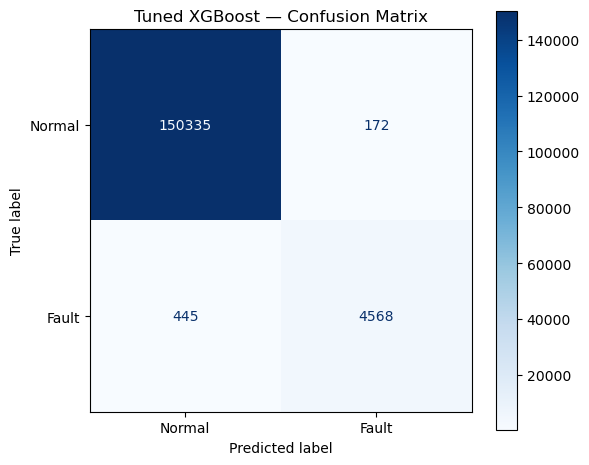

In [74]:
param_dist = {
    'n_estimators'    : [100, 200, 300, 400],
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
}

base_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1),
    max_depth=5,
    tree_method='hist',
    random_state=42, n_jobs=1
)

tscv_tune = TimeSeriesSplit(n_splits=2)  

rs = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=8,        
    scoring='f1_weighted',
    cv=tscv_tune,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit=True       
)

rs.fit(X_train_sel, y_train)

print(f"\nBest CV weighted-F1 : {rs.best_score_:.4f}")
print(f"Best parameters     :")
for k, v in rs.best_params_.items():
    print(f"   {k:20s}: {v}")

xgb_best = rs.best_estimator_
y_pred_best = xgb_best.predict(X_test_sel)

print("\n" + "="*55)
print("TUNED XGBoost - Test Set Performance")
print("="*55)
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Fault']))
print(f"Accuracy    : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Weighted F1 : {f1_score(y_test, y_pred_best, average='weighted'):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Normal', 'Fault']
).plot(ax=ax, cmap='Blues')
ax.set_title("Tuned XGBoost , Confusion Matrix")
plt.tight_layout()
plt.savefig("09_tuned_xgb_cm.png", dpi=150, bbox_inches='tight')
plt.show()


## Unsupervised Baseline: Isolation Forest

In many industrial settings, fault labels don't exist at deployment time, the system encounters new operating conditions that haven't been seen before. Isolation Forest is an entirely unsupervised anomaly detector: it learns what "normal" looks like from the training data and flags anything that deviates from it, with no knowledge of fault labels at all.

Running it here serves two purposes. It gives us a baseline to compare against the supervised model, and it answers a practical question: *how much value does fault labelling actually add?* The gap between the unsupervised and supervised performance is a direct measure of how much the labels contributed.

IsolationForest (UNSUPERVISED) — Test Set Performance
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99    150507
       Fault       0.77      0.51      0.61      5013

    accuracy                           0.98    155520
   macro avg       0.88      0.75      0.80    155520
weighted avg       0.98      0.98      0.98    155520


IsolationForest  → Accuracy=0.9792  F1=0.9771
Tuned XGBoost    → Accuracy=0.9960  F1=0.9960

Labeling benefit: +1.9 F1 points from supervised learning


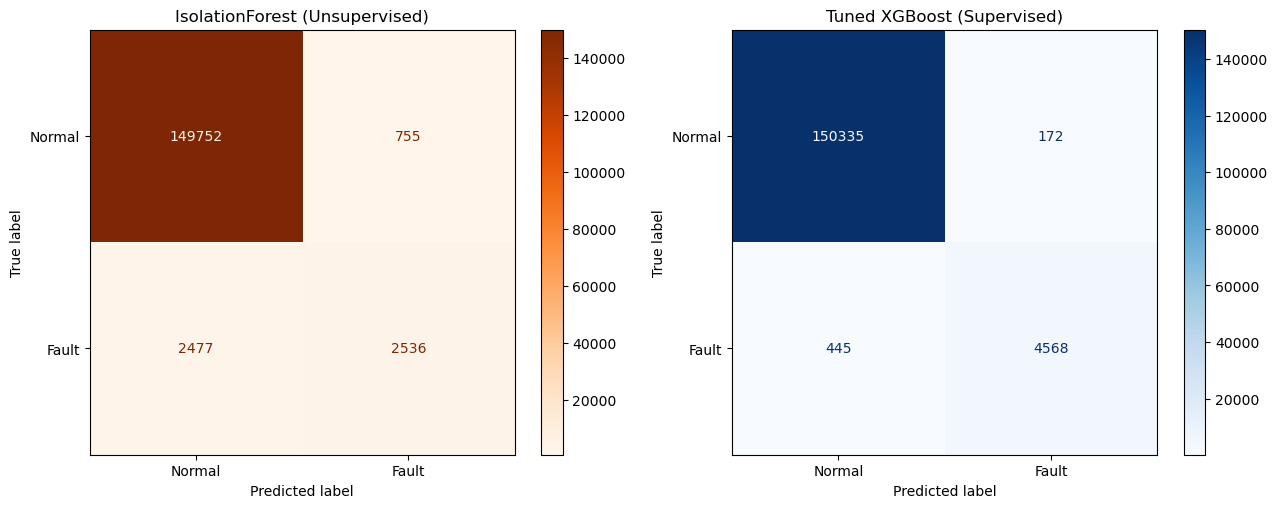

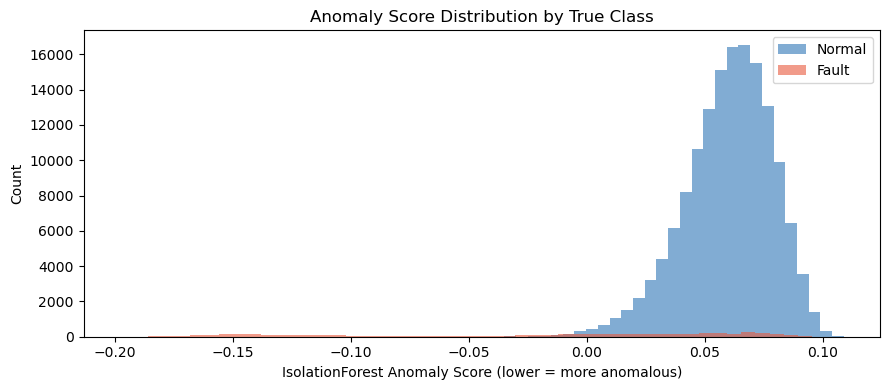

In [76]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_sel)

iso_raw = iso_forest.predict(X_test_sel)

y_pred_iso = (iso_raw == -1).astype(int)

print("="*55)
print("IsolationForest (UNSUPERVISED) , Test Set Performance")
print("="*55)
print(classification_report(y_test, y_pred_iso, target_names=['Normal', 'Fault'],
                             zero_division=0))

iso_f1  = f1_score(y_test, y_pred_iso, average='weighted', zero_division=0)
iso_acc = accuracy_score(y_test, y_pred_iso)
sup_f1  = f1_score(y_test, y_pred_best, average='weighted')
sup_acc = accuracy_score(y_test, y_pred_best)

print(f"\nIsolationForest  → Accuracy={iso_acc:.4f}  F1={iso_f1:.4f}")
print(f"Tuned XGBoost    → Accuracy={sup_acc:.4f}  F1={sup_f1:.4f}")
print(f"\nLabeling benefit: +{(sup_f1 - iso_f1)*100:.1f} F1 points from supervised learning")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_iso),
    display_labels=['Normal', 'Fault']
).plot(ax=axes[0], cmap='Oranges')
axes[0].set_title("IsolationForest (Unsupervised)")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Normal', 'Fault']
).plot(ax=axes[1], cmap='Blues')
axes[1].set_title("Tuned XGBoost (Supervised)")

plt.tight_layout()
plt.savefig("10_isolation_vs_xgb.png", dpi=150, bbox_inches='tight')
plt.show()

iso_scores = iso_forest.decision_function(X_test_sel) 

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(iso_scores[y_test == 0], bins=50, alpha=0.6, color='#2E75B6', label='Normal')
ax.hist(iso_scores[y_test == 1], bins=50, alpha=0.6, color='#E8593C', label='Fault')
ax.set_xlabel("IsolationForest Anomaly Score (lower = more anomalous)")
ax.set_ylabel("Count")
ax.set_title("Anomaly Score Distribution by True Class")
ax.legend()
plt.tight_layout()
plt.savefig("11_isolation_score_dist.png", dpi=150, bbox_inches='tight')
plt.show()

## SHAP Analysis of Binary Fault Detection

Knowing that the model works is useful. Knowing why it fires on a particular reading is what makes it actionable for a process engineer. SHAP (SHapley Additive exPlanations) assigns each feature a numerical contribution to each individual prediction, features that push the model toward predicting a fault get positive values, features that push it toward normal get negative ones.

We use `TreeExplainer` here because it computes exact SHAP values for gradient boosted trees in linear time, without approximation. The beeswarm plot shows the distribution of these contributions across the entire test set, so you can see not just which features matter but in which direction and how consistently.

SHAP computed for 2000 test samples, 30 features.


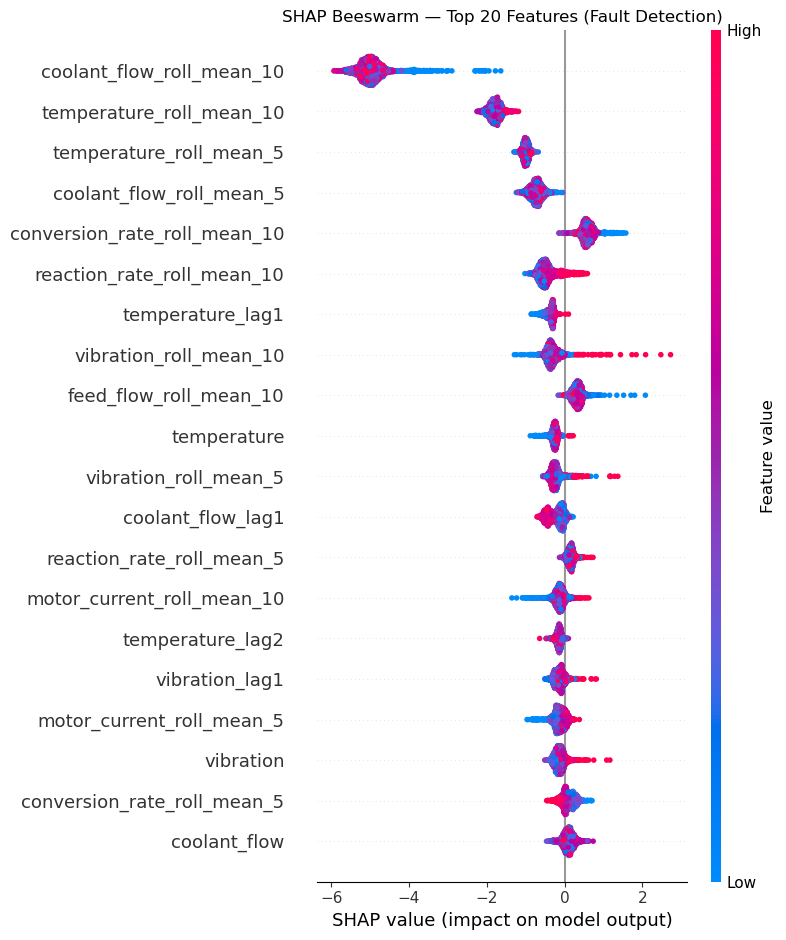

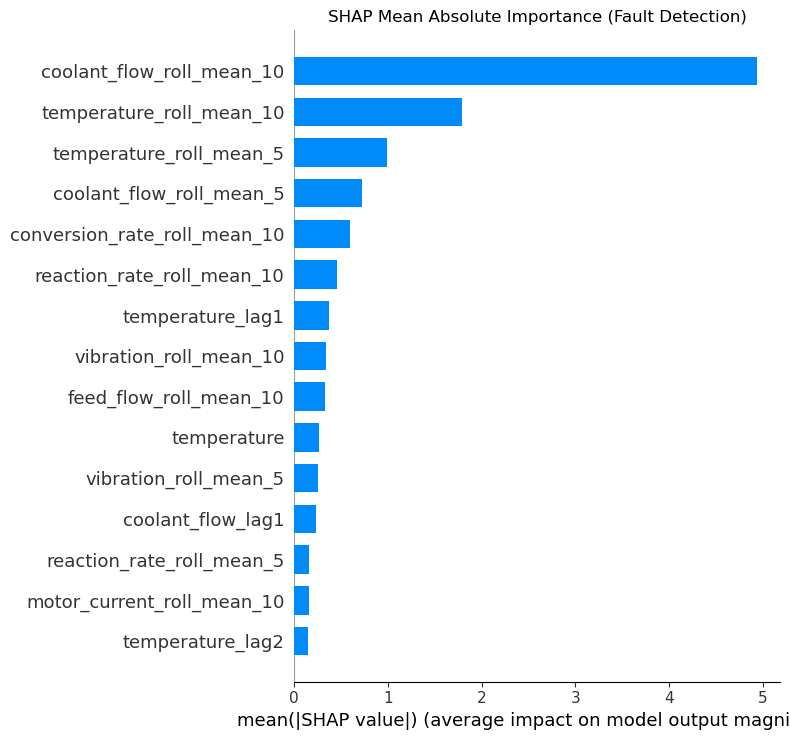

In [78]:
explainer = shap.TreeExplainer(xgb_best)

MAX_SHAP = min(2000, len(X_test_sel))
X_shap   = X_test_sel[:MAX_SHAP]
shap_vals = explainer.shap_values(X_shap)

if isinstance(shap_vals, list):
    shap_fault = shap_vals[1]
else:
    shap_fault = shap_vals

SELECTED_BIN = [FEATURE_COLS[i] for i in range(len(FEATURE_COLS)) if selected_mask_bin[i]]

print(f"SHAP computed for {MAX_SHAP} test samples, {len(SELECTED_BIN)} features.")

shap.summary_plot(shap_fault, X_shap,
                  feature_names=SELECTED_BIN,
                  show=False, max_display=20)
plt.title("SHAP Beeswarm , Top 20 Features (Fault Detection)", fontsize=12)
plt.tight_layout()
plt.savefig("12_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

shap.summary_plot(shap_fault, X_shap,
                  feature_names=SELECTED_BIN,
                  plot_type='bar',
                  show=False, max_display=15)
plt.title("SHAP Mean Absolute Importance (Fault Detection)", fontsize=12)
plt.tight_layout()
plt.savefig("13_shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

In [79]:
fault_indices = np.where((y_test[:MAX_SHAP] == 1) & (y_pred_best[:MAX_SHAP] == 1))[0]

if len(fault_indices) > 0:
    idx = fault_indices[0]
    print(f"Showing SHAP waterfall for test sample {idx} (true=fault, pred=fault)")

    shap_exp = shap.Explanation(
        values     = shap_fault[idx],
        base_values= explainer.expected_value if not isinstance(explainer.expected_value, list)
                     else explainer.expected_value[1],
        data       = X_shap[idx],
        feature_names = SELECTED_BIN
    )
    shap.waterfall_plot(shap_exp, show=False, max_display=15)
    plt.title(f"SHAP Waterfall , Sample {idx} (Correctly Detected Fault)")
    plt.tight_layout()
    plt.savefig("14_shap_waterfall.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No correctly predicted fault samples in SHAP subset , skipping waterfall.")


No correctly predicted fault samples in SHAP subset — skipping waterfall.


The beeswarm makes the model's reasoning transparent: features that appear at the top drive predictions most strongly, and the colour shows whether high or low feature values are associated with fault predictions. In a chemical process context, if a rolling standard deviation feature consistently shows high positive SHAP values, that means volatility in that sensor is a reliable precursor to faults, which could guide where to invest in real-time monitoring.

## Regression: Predicting Efficiency Loss

Detection tells you *that* something is wrong. Efficiency loss tells you *how bad* it is. A 2% loss might be acceptable; a 40% loss demands immediate intervention. We set this up as a regression problem, predicting the continuous `efficiency_loss_pct` value using the same sensor features.

Both Random Forest and XGBoost regressors are trained with the same time-based split. Performance is measured with MAE (how far off on average), RMSE (which penalises large errors more heavily), and R² (what fraction of the variance the model explains). The residual plot helps identify whether errors are random or whether the model systematically under- or over-predicts in certain operating ranges.

In [82]:
mask = df_feat[TARGET_REG].notna().values
df_reg = df_feat.loc[mask]
df_reg = df_reg.sort_values(['reactor_id', 'timestamp'])

X_reg_tr_list, X_reg_te_list = [], []
y_reg_tr_list, y_reg_te_list = [], []

train_sizes, test_sizes = [], []

for _, group in df_reg.groupby('reactor_id'):
    split_time = group['timestamp'].quantile(0.8)

    train_part = group[group['timestamp'] <= split_time]
    test_part  = group[group['timestamp'] >  split_time]

    train_sizes.append(len(train_part))
    test_sizes.append(len(test_part))

    X_reg_tr_list.append(train_part[FEATURE_COLS].to_numpy(dtype=np.float32))
    X_reg_te_list.append(test_part[FEATURE_COLS].to_numpy(dtype=np.float32))

    y_reg_tr_list.append(train_part[TARGET_REG].values.astype(np.float32))
    y_reg_te_list.append(test_part[TARGET_REG].values.astype(np.float32))

X_reg_tr = np.concatenate(X_reg_tr_list, axis=0)
X_reg_te = np.concatenate(X_reg_te_list, axis=0)
y_reg_tr = np.concatenate(y_reg_tr_list)
y_reg_te = np.concatenate(y_reg_te_list)

rf = RandomForestRegressor(
    n_estimators=50, max_depth=10,
    random_state=42, n_jobs=-1
)

rf.fit(X_reg_tr, y_reg_tr)

importances = rf.feature_importances_
top_idx = np.argsort(importances)[-N_TOP_FEATURES:]

X_reg_tr_s = X_reg_tr[:, top_idx]
X_reg_te_s = X_reg_te[:, top_idx]

print(f"Regression train size: {sum(train_sizes):,}")
print(f"Regression test size : {sum(test_sizes):,}")
print(f"Selected {len(top_idx)} features for regression")

Regression train size: 584,543
Regression test size : 146,138
Selected 30 features for regression


In [83]:
rf_reg = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=5,
    random_state=42, n_jobs=-1
)
rf_reg.fit(X_reg_tr_s, y_reg_tr)
y_rf_reg = rf_reg.predict(X_reg_te_s)

print("Random Forest Regressor")
print(f"  MAE  : {mean_absolute_error(y_reg_te, y_rf_reg):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_reg_te, y_rf_reg))}")
print(f"  R²   : {r2_score(y_reg_te, y_rf_reg):.4f}")

xgb_reg = XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    objective='reg:squarederror', eval_metric='rmse',
    random_state=42, n_jobs=-1, tree_method='hist'
)
xgb_reg.fit(
    X_reg_tr_s, y_reg_tr,
    eval_set=[(X_reg_te_s, y_reg_te)],
    verbose=False
)
y_xgb_reg = xgb_reg.predict(X_reg_te_s)

print("\nXGBoost Regressor")
print(f"  MAE  : {mean_absolute_error(y_reg_te, y_xgb_reg):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_reg_te, y_rf_reg)):.4f}")
print(f"  R²   : {r2_score(y_reg_te, y_xgb_reg):.4f}")


Random Forest Regressor
  MAE  : 0.0920
  RMSE : 0.6119668884309108
  R²   : 0.9561

XGBoost Regressor
  MAE  : 0.1075
  RMSE : 0.6120
  R²   : 0.9529


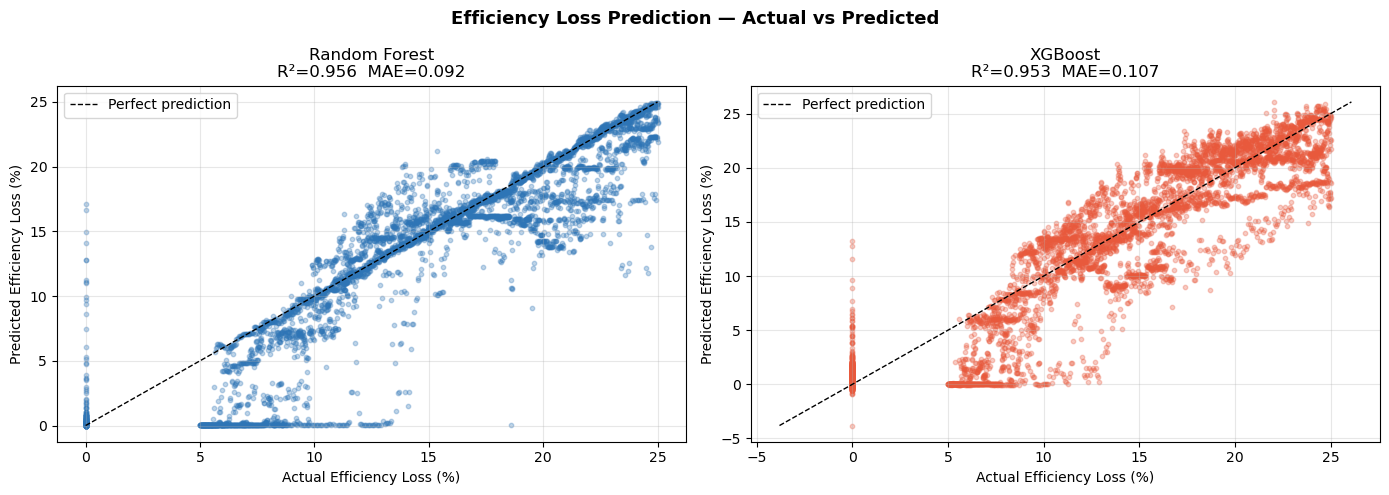

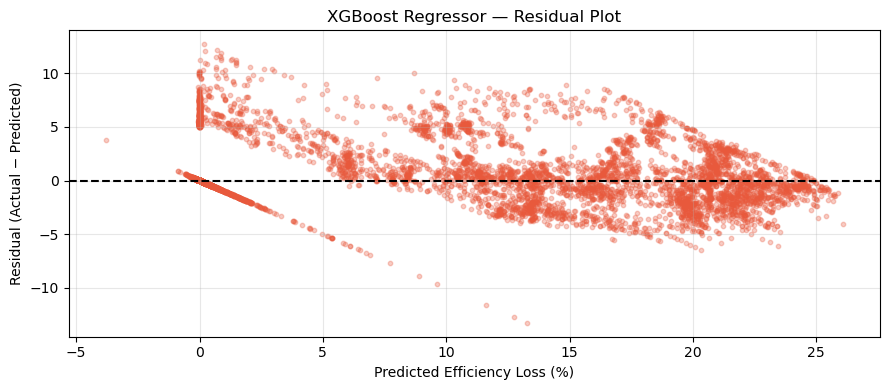

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred_r, label, color in zip(
    axes,
    [y_rf_reg, y_xgb_reg],
    ['Random Forest', 'XGBoost'],
    ['#2E75B6', '#E8593C']
):
    ax.scatter(y_reg_te, y_pred_r, alpha=0.3, s=10, color=color)
    mn = min(y_reg_te.min(), y_pred_r.min())
    mx = max(y_reg_te.max(), y_pred_r.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1, label='Perfect prediction')
    r2 = r2_score(y_reg_te, y_pred_r)
    mae = mean_absolute_error(y_reg_te, y_pred_r)
    ax.set_title(f"{label}\nR²={r2:.3f}  MAE={mae:.3f}")
    ax.set_xlabel("Actual Efficiency Loss (%)")
    ax.set_ylabel("Predicted Efficiency Loss (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Efficiency Loss Prediction , Actual vs Predicted",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("15_regression_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
residuals = y_reg_te - y_xgb_reg
ax.scatter(y_xgb_reg, residuals, alpha=0.3, s=10, color='#E8593C')
ax.axhline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel("Predicted Efficiency Loss (%)")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("XGBoost Regressor , Residual Plot")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("16_regression_residuals.png", dpi=150, bbox_inches='tight')
plt.show()


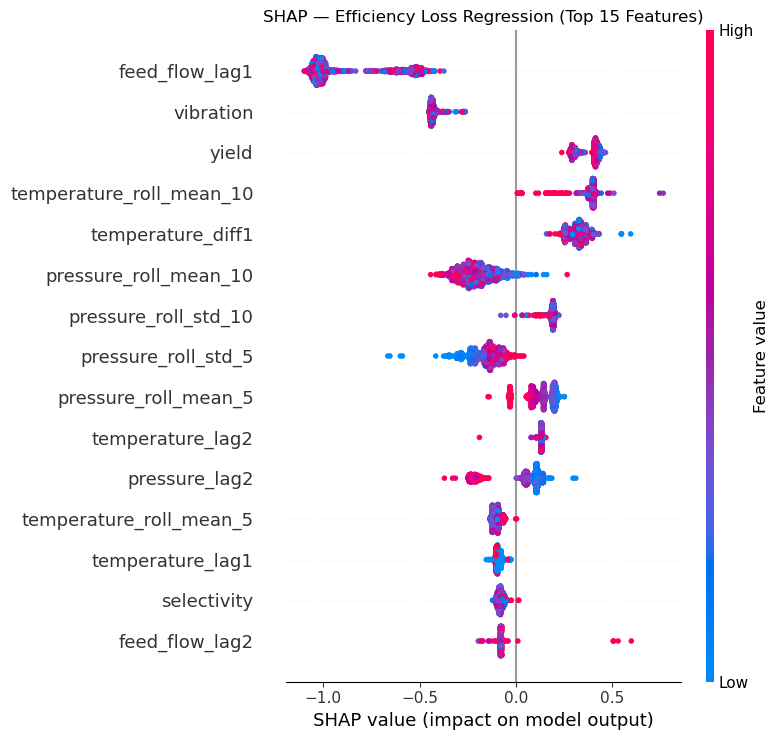

In [104]:
explainer_reg = shap.TreeExplainer(xgb_reg)

MAX_SHAP_REG = min(2000, len(X_reg_te_s))
X_shap_reg   = X_reg_te_s[:MAX_SHAP_REG]
shap_reg_vals = explainer_reg.shap_values(X_shap_reg)

SELECTED_REG_FEATS = FEATURE_COLS[:X_shap_reg.shape[1]]

shap.summary_plot(
    shap_reg_vals,
    X_shap_reg,
    feature_names=SELECTED_REG_FEATS,
    show=False,
    max_display=15
)

plt.title("SHAP , Efficiency Loss Regression (Top 15 Features)", fontsize=12)
plt.tight_layout()
plt.savefig("17_shap_regression.png", dpi=150, bbox_inches='tight')
plt.show()

## Multi-Class Fault Classification

Now that binary detection is working reliably, we can tackle the harder question: given that a fault is occurring, which type is it? By restricting the training data to fault-only rows, we sidestep the normal-vs-fault imbalance that crippled the first attempt. The remaining challenge is distinguishing between fault types that may look similar in sensor space.

Three classifiers are compared: Random Forest, XGBoost, and LightGBM. All three are trained on SMOTE-balanced data so that rare fault types get proportional representation. Each uses its own label encoder because XGBoost and LightGBM require zero-indexed contiguous integer labels.

In [107]:
train_mc = train_df[train_df['fault_encoded'] != 0].copy()
test_mc  = test_df[test_df['fault_encoded']  != 0].copy()

print("Rows after removing normal class:")
print("Train:", len(train_mc))
print("Test :", len(test_mc))

Rows after removing normal class:
Train: 22888
Test : 5013


In [108]:
all_labels = pd.concat([
    train_mc['fault_type'].astype(str),
    test_mc['fault_type'].astype(str)
]).dropna().unique()

le_fault = LabelEncoder()
le_fault.fit(all_labels)

train_mc['fault_mc'] = le_fault.transform(train_mc['fault_type'].astype(str))
test_mc['fault_mc']  = le_fault.transform(test_mc['fault_type'].astype(str))

CLASS_NAMES_MC = list(le_fault.classes_)
N_CLASSES      = len(CLASS_NAMES_MC)

print("\nFault classes used:")
for i, name in enumerate(CLASS_NAMES_MC):
    print(f"{i}: {name}")

train_classes = set(train_mc['fault_mc'].unique())
test_classes  = set(test_mc['fault_mc'].unique())
missing_train = sorted(set(range(N_CLASSES)) - train_classes)
missing_test  = sorted(set(range(N_CLASSES)) - test_classes)

if missing_train:
    print("\nWarning: classes missing in TRAIN:", [CLASS_NAMES_MC[i] for i in missing_train])
if missing_test:
    print("\nNote: classes missing in TEST:", [CLASS_NAMES_MC[i] for i in missing_test])


Fault classes used:
0: 1
1: 2
2: 3
3: 4


In [109]:
feature_cols_mc = SELECTED_FEATURES if 'SELECTED_FEATURES' in globals() and len(SELECTED_FEATURES) > 0 else FEATURE_COLS

train_mc = train_mc.dropna(subset=feature_cols_mc + ['fault_mc']).copy()
test_mc  = test_mc.dropna(subset=feature_cols_mc + ['fault_mc']).copy()

X_mc_tr_raw = train_mc[feature_cols_mc].values
X_mc_te_raw = test_mc[feature_cols_mc].values
y_mc_tr     = train_mc['fault_mc'].values
y_mc_te     = test_mc['fault_mc'].values

scaler_mc = StandardScaler()
X_mc_tr   = scaler_mc.fit_transform(X_mc_tr_raw)
X_mc_te   = scaler_mc.transform(X_mc_te_raw)

train_counts = pd.Series(y_mc_tr).value_counts().sort_index()
min_count    = train_counts.min()

if min_count < 2:
    sampler = RandomOverSampler(random_state=42)
else:
    k_neighbors = min(5, min_count - 1)
    sampler = SMOTE(random_state=42, k_neighbors=k_neighbors)

X_mc_tr_sm, y_mc_tr_sm = sampler.fit_resample(X_mc_tr, y_mc_tr)

print("Train class counts after SMOTE:")
for cls, cnt in pd.Series(y_mc_tr_sm).value_counts().sort_index().items():
    print(f"  {CLASS_NAMES_MC[cls]:30s}: {cnt}")

Train class counts after SMOTE:
  1                             : 6530
  2                             : 6530
  3                             : 6530
  4                             : 6530



RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           1       0.99      0.71      0.83      2613
           2       0.75      0.96      0.84       654
           3       0.27      0.61      0.37       353
           4       0.92      0.99      0.95      1393

    accuracy                           0.81      5013
   macro avg       0.73      0.82      0.75      5013
weighted avg       0.89      0.81      0.83      5013



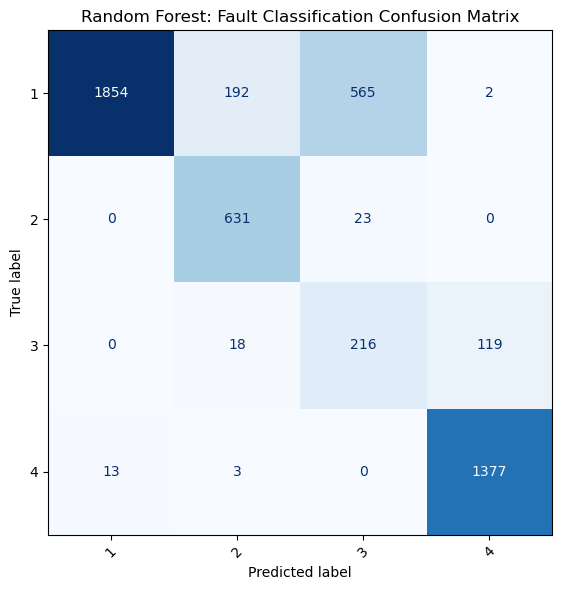

Accuracy         : 0.8135
Weighted F1      : 0.8323
Macro F1         : 0.7490
Balanced Accuracy: 0.8187


In [110]:
labels_present_mc = np.unique(np.concatenate([y_mc_te, y_mc_tr]))
labels_present_mc = np.array([l for l in labels_present_mc if l < len(CLASS_NAMES_MC)])

rf_mc = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, random_state=42, n_jobs=-1
)
rf_mc.fit(X_mc_tr_sm, y_mc_tr_sm)
y_pred_rf_mc = rf_mc.predict(X_mc_te)

print("\n" + "="*60)
print("RANDOM FOREST RESULTS")
print("="*60)
labels_in_test = np.unique(np.concatenate([y_mc_te, y_pred_rf_mc]))
print(classification_report(
    y_mc_te, y_pred_rf_mc,
    labels=labels_in_test,
    target_names=[CLASS_NAMES_MC[i] for i in labels_in_test],
    zero_division=0
))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_mc_te, y_pred_rf_mc, labels=labels_in_test),
    display_labels=[CLASS_NAMES_MC[i] for i in labels_in_test]
).plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title("Random Forest: Fault Classification Confusion Matrix")
plt.tight_layout()
plt.show()

rf_mc_acc = accuracy_score(y_mc_te, y_pred_rf_mc)
rf_mc_f1w = f1_score(y_mc_te, y_pred_rf_mc, average='weighted', zero_division=0)
rf_mc_f1m = f1_score(y_mc_te, y_pred_rf_mc, average='macro',    zero_division=0)
rf_mc_bac = balanced_accuracy_score(y_mc_te, y_pred_rf_mc)
print(f"Accuracy         : {rf_mc_acc:.4f}")
print(f"Weighted F1      : {rf_mc_f1w:.4f}")
print(f"Macro F1         : {rf_mc_f1m:.4f}")
print(f"Balanced Accuracy: {rf_mc_bac:.4f}")



XGBOOST RESULTS
              precision    recall  f1-score   support

           1       1.00      0.55      0.71      2613
           2       0.94      0.96      0.95       654
           3       0.16      0.63      0.25       353
           4       0.91      0.99      0.95      1393

    accuracy                           0.73      5013
   macro avg       0.75      0.78      0.72      5013
weighted avg       0.91      0.73      0.78      5013

Accuracy         : 0.7313
Weighted F1      : 0.7757
Macro F1         : 0.7162
Balanced Accuracy: 0.7824


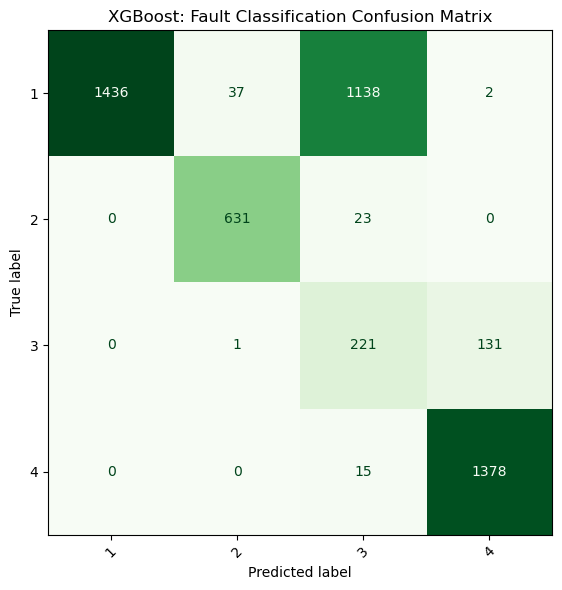

In [111]:
le_xgb_mc = LabelEncoder()
y_xgb_tr_e = le_xgb_mc.fit_transform(y_mc_tr_sm)
y_xgb_te_e = le_xgb_mc.transform(y_mc_te)

xgb_mc = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    objective='multi:softprob', num_class=N_CLASSES,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, tree_method='hist'
)
xgb_mc.fit(X_mc_tr_sm, y_xgb_tr_e,
           eval_set=[(X_mc_te, y_xgb_te_e)], verbose=False)

y_pred_xgb_mc = le_xgb_mc.inverse_transform(xgb_mc.predict(X_mc_te))

print("\n" + "="*60)
print("XGBOOST RESULTS")
print("="*60)
print(classification_report(y_mc_te, y_pred_xgb_mc,
      labels=labels_in_test,
      target_names=[CLASS_NAMES_MC[i] for i in labels_in_test],
      zero_division=0))

xgb_mc_acc = accuracy_score(y_mc_te, y_pred_xgb_mc)
xgb_mc_f1w = f1_score(y_mc_te, y_pred_xgb_mc, average='weighted', zero_division=0)
xgb_mc_f1m = f1_score(y_mc_te, y_pred_xgb_mc, average='macro',    zero_division=0)
xgb_mc_bac = balanced_accuracy_score(y_mc_te, y_pred_xgb_mc)
print(f"Accuracy         : {xgb_mc_acc:.4f}")
print(f"Weighted F1      : {xgb_mc_f1w:.4f}")
print(f"Macro F1         : {xgb_mc_f1m:.4f}")
print(f"Balanced Accuracy: {xgb_mc_bac:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_mc_te, y_pred_xgb_mc, labels=labels_in_test),
    display_labels=[CLASS_NAMES_MC[i] for i in labels_in_test]
).plot(ax=ax, cmap='Greens', colorbar=False, xticks_rotation=45)
ax.set_title("XGBoost: Fault Classification Confusion Matrix")
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7403
[LightGBM] [Info] Number of data points in the train set: 26120, number of used features: 30
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

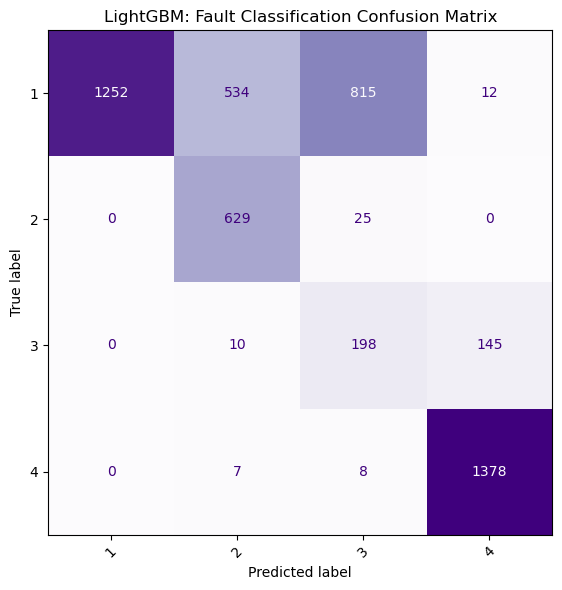

In [112]:
le_lgb_mc = LabelEncoder()
y_lgb_tr_e = le_lgb_mc.fit_transform(y_mc_tr_sm)
y_lgb_te_e = le_lgb_mc.transform(y_mc_te)

N_CLASSES_LGB = len(le_lgb_mc.classes_)
cw_lgb = compute_class_weight('balanced', classes=np.unique(y_lgb_tr_e), y=y_lgb_tr_e)
cw_dict_lgb = {i: w for i, w in enumerate(cw_lgb)}

lgb_mc = lgb.LGBMClassifier(
    objective='multiclass', num_class=N_CLASSES_LGB,
    n_estimators=500, learning_rate=0.05,
    max_depth=-1, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    class_weight=cw_dict_lgb, random_state=42, n_jobs=-1
)
lgb_mc.fit(X_mc_tr_sm, y_lgb_tr_e,
           eval_set=[(X_mc_te, y_lgb_te_e)], eval_metric='multi_logloss')

y_pred_lgb_mc = le_lgb_mc.inverse_transform(lgb_mc.predict(X_mc_te))

print(classification_report(y_mc_te, y_pred_lgb_mc,
      labels=labels_in_test,
      target_names=[CLASS_NAMES_MC[i] for i in labels_in_test],
      zero_division=0))

lgb_mc_acc = accuracy_score(y_mc_te, y_pred_lgb_mc)
lgb_mc_f1w = f1_score(y_mc_te, y_pred_lgb_mc, average='weighted', zero_division=0)
lgb_mc_f1m = f1_score(y_mc_te, y_pred_lgb_mc, average='macro',    zero_division=0)
lgb_mc_bac = balanced_accuracy_score(y_mc_te, y_pred_lgb_mc)
print(f"Accuracy         : {lgb_mc_acc:.4f}")
print(f"Weighted F1      : {lgb_mc_f1w:.4f}")
print(f"Macro F1         : {lgb_mc_f1m:.4f}")
print(f"Balanced Accuracy: {lgb_mc_bac:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_mc_te, y_pred_lgb_mc, labels=labels_in_test),
    display_labels=[CLASS_NAMES_MC[i] for i in labels_in_test]
).plot(ax=ax, cmap='Purples', colorbar=False, xticks_rotation=45)
ax.set_title("LightGBM: Fault Classification Confusion Matrix")
plt.tight_layout()
plt.show()

### Cross-Validation for Fault Classification

The same `TimeSeriesSplit` approach used for binary detection is applied here, but with one additional complication: fault-only data is sparser, so some folds may have very few samples of certain classes. SMOTE is applied inside each fold independently, applying it before splitting would synthesise samples from future data into the training set, which would be a form of leakage.

This gives us fold-by-fold confidence intervals on weighted F1, macro F1, and balanced accuracy.

TimeSeriesSplit CV: Fault Classification (XGBoost)
  Fold 1: Weighted-F1=0.7268  Macro-F1=0.5317  Bal-Acc=0.6983
  Fold 2: Weighted-F1=0.6145  Macro-F1=0.5926  Bal-Acc=0.7139
  Fold 3: Weighted-F1=0.6385  Macro-F1=0.5812  Bal-Acc=0.6912
  Fold 4: Weighted-F1=0.6482  Macro-F1=0.4392  Bal-Acc=0.5442
  Fold 5: Weighted-F1=0.7184  Macro-F1=0.6828  Bal-Acc=0.7664

CV Weighted-F1 : 0.6693 ± 0.0450
CV Macro-F1    : 0.5655 ± 0.0798
CV Bal-Accuracy: 0.6828 ± 0.0741


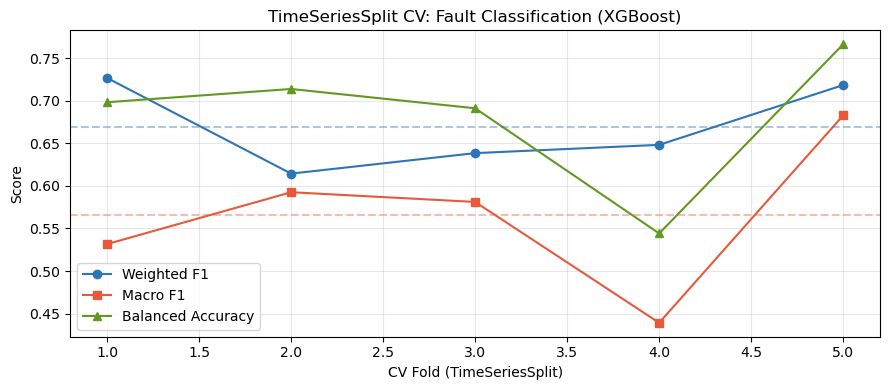

In [114]:
df_mc_all = pd.concat([train_mc, test_mc]).sort_values('timestamp').reset_index(drop=True)
X_mc_all_raw = df_mc_all[feature_cols_mc].values
y_mc_all     = df_mc_all['fault_mc'].values

scaler_mc_cv = StandardScaler()
X_mc_all_sc  = scaler_mc_cv.fit_transform(X_mc_all_raw)

tscv_mc = TimeSeriesSplit(n_splits=5)

cv_mc_f1w  = []
cv_mc_f1m  = []
cv_mc_bac  = []

print("TimeSeriesSplit CV: Fault Classification (XGBoost)")
print("="*60)

for fold, (tr_idx, te_idx) in enumerate(tscv_mc.split(X_mc_all_sc)):
    X_cv_tr, X_cv_te = X_mc_all_sc[tr_idx], X_mc_all_sc[te_idx]
    y_cv_tr, y_cv_te = y_mc_all[tr_idx],    y_mc_all[te_idx]

    counts = pd.Series(y_cv_tr).value_counts()
    if counts.min() < 2 or len(counts) < 2:
        print(f"  Fold {fold+1}: skipped (insufficient class samples in train)")
        continue

    k_nb = min(5, counts.min() - 1)
    try:
        sm = SMOTE(random_state=42, k_neighbors=k_nb)
        X_sm, y_sm = sm.fit_resample(X_cv_tr, y_cv_tr)
    except Exception:
        ros = RandomOverSampler(random_state=42)
        X_sm, y_sm = ros.fit_resample(X_cv_tr, y_cv_tr)

    le_cv = LabelEncoder()
    y_sm_e  = le_cv.fit_transform(y_sm)
    mask_te = np.isin(y_cv_te, le_cv.classes_)
    if mask_te.sum() == 0:
        print(f"  Fold {fold+1}: skipped (no overlap between train/test classes)")
        continue
    y_cv_te_f  = y_cv_te[mask_te]
    X_cv_te_f  = X_cv_te[mask_te]
    y_cv_te_e  = le_cv.transform(y_cv_te_f)

    n_cls = len(le_cv.classes_)
    cv_xgb = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        objective='multi:softprob', num_class=n_cls,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, tree_method='hist',
        verbosity=0
    )
    cv_xgb.fit(X_sm, y_sm_e)
    y_cv_pred_e = cv_xgb.predict(X_cv_te_f)

    f1w = f1_score(y_cv_te_e, y_cv_pred_e, average='weighted', zero_division=0)
    f1m = f1_score(y_cv_te_e, y_cv_pred_e, average='macro',    zero_division=0)
    bac = balanced_accuracy_score(y_cv_te_e, y_cv_pred_e)
    cv_mc_f1w.append(f1w)
    cv_mc_f1m.append(f1m)
    cv_mc_bac.append(bac)
    print(f"  Fold {fold+1}: Weighted-F1={f1w:.4f}  Macro-F1={f1m:.4f}  Bal-Acc={bac:.4f}")

if cv_mc_f1w:
    print(f"\nCV Weighted-F1 : {np.mean(cv_mc_f1w):.4f} ± {np.std(cv_mc_f1w):.4f}")
    print(f"CV Macro-F1    : {np.mean(cv_mc_f1m):.4f} ± {np.std(cv_mc_f1m):.4f}")
    print(f"CV Bal-Accuracy: {np.mean(cv_mc_bac):.4f} ± {np.std(cv_mc_bac):.4f}")

    folds_ran = np.arange(1, len(cv_mc_f1w) + 1)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(folds_ran, cv_mc_f1w, marker='o', label='Weighted F1',     color='#2E75B6')
    ax.plot(folds_ran, cv_mc_f1m, marker='s', label='Macro F1',        color='#E8593C')
    ax.plot(folds_ran, cv_mc_bac, marker='^', label='Balanced Accuracy',color='#639922')
    ax.axhline(np.mean(cv_mc_f1w), linestyle='--', color='#2E75B6', alpha=0.4)
    ax.axhline(np.mean(cv_mc_f1m), linestyle='--', color='#E8593C', alpha=0.4)
    ax.set_xlabel("CV Fold (TimeSeriesSplit)")
    ax.set_ylabel("Score")
    ax.set_title("TimeSeriesSplit CV: Fault Classification (XGBoost)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("18_mc_cv.png", dpi=150, bbox_inches='tight')
    plt.show()

### Hyperparameter Tuning for Fault Classification

Multi-class problems often need different hyperparameter settings than binary ones. More classes means more decision boundaries, which typically benefits from slightly deeper trees and more conservative learning rates. We run a separate `RandomizedSearchCV` for this task rather than reusing the binary detection search results.

The default and tuned confusion matrices are plotted side by side so the improvement (or lack of it) from tuning is visually clear.

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best CV weighted-F1 : nan
Best parameters:
   subsample           : 0.8
   n_estimators        : 500
   min_child_weight    : 2
   max_depth           : 5
   learning_rate       : 0.05
   gamma               : 0.3
   colsample_bytree    : 0.7

TUNED XGBoost: Fault Classification (Test Set)
              precision    recall  f1-score   support

           1       1.00      0.59      0.74      2613
           2       0.92      0.96      0.94       654
           3       0.18      0.63      0.28       353
           4       0.89      0.99      0.93      1393

    accuracy                           0.75      5013
   macro avg       0.75      0.79      0.72      5013
weighted avg       0.90      0.75      0.79      5013

Accuracy         : 0.7528
Weighted F1      : 0.7896
Macro F1         : 0.7241
Balanced Accuracy: 0.7919


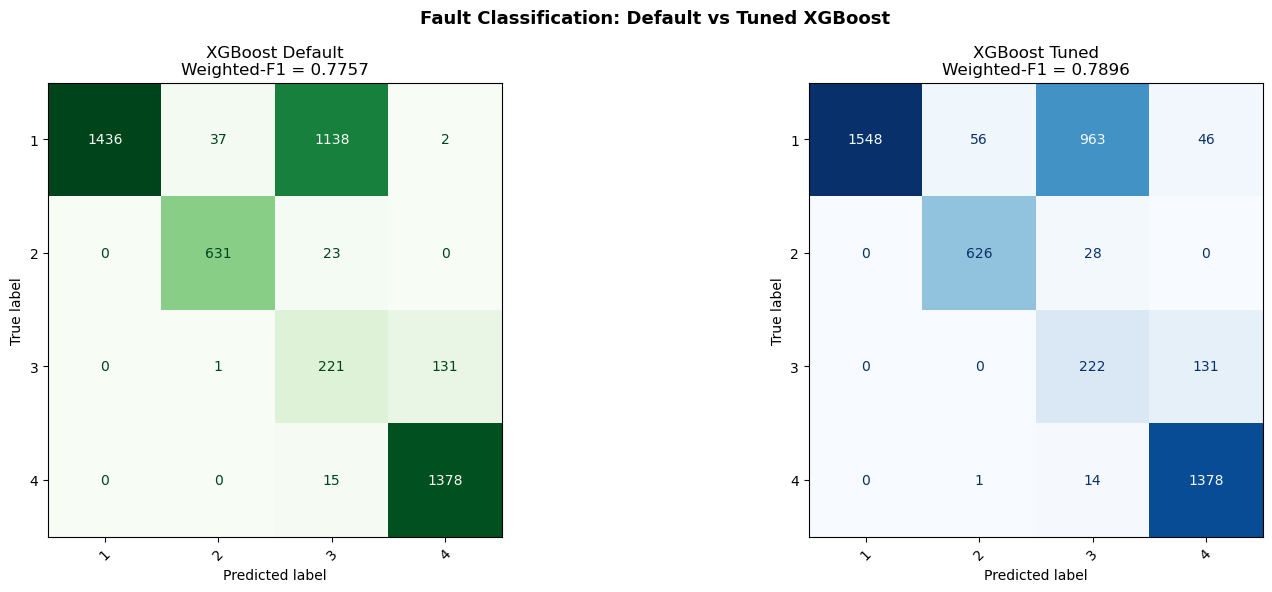


Improvement from tuning:
  Weighted-F1  : 0.7757 -> 0.7896  (+1.39 pts)
  Macro-F1     : 0.7162 -> 0.7241  (+0.79 pts)
  Bal-Accuracy : 0.7824 -> 0.7919  (+0.95 pts)


In [116]:
le_tune_mc = LabelEncoder()
y_mc_tr_enc = le_tune_mc.fit_transform(y_mc_tr_sm)  
y_mc_te_enc = le_tune_mc.transform(y_mc_te)         

N_CLS_TUNE = len(le_tune_mc.classes_)

param_dist_mc = {
    'n_estimators'    : [200, 300, 400, 500],
    'max_depth'       : [4, 5, 6, 7, 8],       
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 2, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.3],    
}

base_xgb_mc = XGBClassifier(
    objective='multi:softprob',
    num_class=N_CLS_TUNE,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    verbosity=0
)

tscv_tune_mc = TimeSeriesSplit(n_splits=3)

rs_mc = RandomizedSearchCV(
    estimator          = base_xgb_mc,
    param_distributions= param_dist_mc,
    n_iter             = 20,
    scoring            = 'f1_weighted',
    cv                 = tscv_tune_mc,
    random_state       = 42,
    n_jobs             = -1,
    verbose            = 1,
    refit              = True    
)

rs_mc.fit(X_mc_tr_sm, y_mc_tr_enc)

print(f"\nBest CV weighted-F1 : {rs_mc.best_score_:.4f}")
print("Best parameters:")
for k, v in rs_mc.best_params_.items():
    print(f"   {k:20s}: {v}")

xgb_mc_best      = rs_mc.best_estimator_
y_pred_mc_tuned_e = xgb_mc_best.predict(X_mc_te)
y_pred_mc_tuned   = le_tune_mc.inverse_transform(y_pred_mc_tuned_e)

print("\n" + "="*60)
print("TUNED XGBoost: Fault Classification (Test Set)")
print("="*60)
print(classification_report(
    y_mc_te, y_pred_mc_tuned,
    labels=labels_in_test,
    target_names=[CLASS_NAMES_MC[i] for i in labels_in_test],
    zero_division=0
))

tuned_mc_acc = accuracy_score(y_mc_te, y_pred_mc_tuned)
tuned_mc_f1w = f1_score(y_mc_te, y_pred_mc_tuned, average='weighted', zero_division=0)
tuned_mc_f1m = f1_score(y_mc_te, y_pred_mc_tuned, average='macro',    zero_division=0)
tuned_mc_bac = balanced_accuracy_score(y_mc_te, y_pred_mc_tuned)

print(f"Accuracy         : {tuned_mc_acc:.4f}")
print(f"Weighted F1      : {tuned_mc_f1w:.4f}")
print(f"Macro F1         : {tuned_mc_f1m:.4f}")
print(f"Balanced Accuracy: {tuned_mc_bac:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tick_labels = [CLASS_NAMES_MC[i] for i in labels_in_test]

ConfusionMatrixDisplay(
    confusion_matrix(y_mc_te, y_pred_xgb_mc, labels=labels_in_test),
    display_labels=tick_labels
).plot(ax=axes[0], cmap='Greens', colorbar=False, xticks_rotation=45)
axes[0].set_title(f"XGBoost Default\nWeighted-F1 = {xgb_mc_f1w:.4f}")

ConfusionMatrixDisplay(
    confusion_matrix(y_mc_te, y_pred_mc_tuned, labels=labels_in_test),
    display_labels=tick_labels
).plot(ax=axes[1], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[1].set_title(f"XGBoost Tuned\nWeighted-F1 = {tuned_mc_f1w:.4f}")

plt.suptitle("Fault Classification: Default vs Tuned XGBoost", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("19_mc_tuning_cm.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImprovement from tuning:")
print(f"  Weighted-F1  : {xgb_mc_f1w:.4f} -> {tuned_mc_f1w:.4f}  ({(tuned_mc_f1w - xgb_mc_f1w)*100:+.2f} pts)")
print(f"  Macro-F1     : {xgb_mc_f1m:.4f} -> {tuned_mc_f1m:.4f}  ({(tuned_mc_f1m - xgb_mc_f1m)*100:+.2f} pts)")
print(f"  Bal-Accuracy : {xgb_mc_bac:.4f} -> {tuned_mc_bac:.4f}  ({(tuned_mc_bac - xgb_mc_bac)*100:+.2f} pts)")

### SHAP Analysis Fault Classification

For fault classification, SHAP is arguably more valuable than for binary detection. When a model says "this is a temperature runaway", the process engineer needs to know which sensor features drove that diagnosis before they can act on it. SHAP gives them that.

Because this is a multi-class model, SHAP produces a separate matrix of values for each fault class. The global importance bar chart averages across all classes. The per-class beeswarms show what specifically distinguishes each fault type from the others. And the waterfall plots trace individual predictions from base rate to final output, one feature at a time.

In [131]:
explainer_mc = shap.TreeExplainer(xgb_mc)

MAX_SHAP_MC = min(2000, len(X_mc_te))
X_shap_mc   = X_mc_te[:MAX_SHAP_MC]

shap_vals_mc = explainer_mc.shap_values(X_shap_mc)

In [133]:
shap_array = np.array(shap_vals_mc)

print("SHAP shape:", shap_array.shape)
print("Feature list length:", len(feature_cols_mc))

SHAP shape: (2000, 30, 4)
Feature list length: 30


SHAP computed: 2000 test samples × 30 features × 4 classes


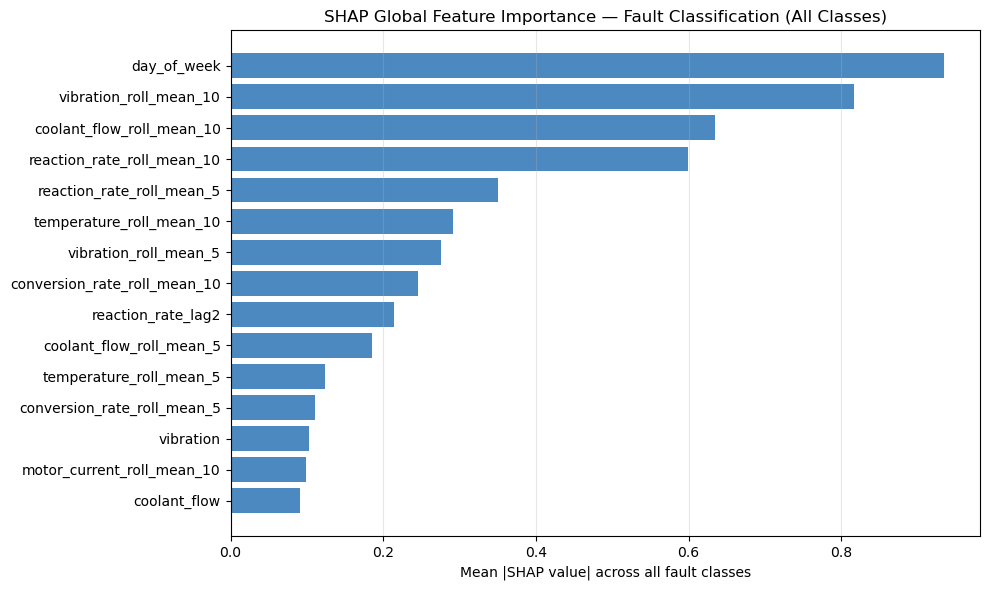

In [150]:
explainer_mc = shap.TreeExplainer(xgb_mc_best)

MAX_SHAP_MC  = min(2000, len(X_mc_te))
X_shap_mc    = X_mc_te[:MAX_SHAP_MC]
y_shap_mc_true = y_mc_te[:MAX_SHAP_MC]

shap_vals_mc = explainer_mc.shap_values(X_shap_mc)

print(f"SHAP computed: {MAX_SHAP_MC} test samples × {len(feature_cols_mc)} features × {N_CLS_TUNE} classes")

shap_array = np.array(shap_vals_mc)

shap_mean = np.mean(np.abs(shap_array), axis=2)

feature_importance = np.mean(shap_mean, axis=0)

mean_importance = pd.DataFrame({
    'feature': feature_cols_mc,
    'mean_abs_shap': feature_importance
}).sort_values('mean_abs_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mean_importance['feature'][::-1], mean_importance['mean_abs_shap'][::-1],
        color='#2E75B6', alpha=0.85)
ax.set_xlabel("Mean |SHAP value| across all fault classes")
ax.set_title("SHAP Global Feature Importance , Fault Classification (All Classes)")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("20_shap_mc_global.png", dpi=150, bbox_inches='tight')
plt.show()

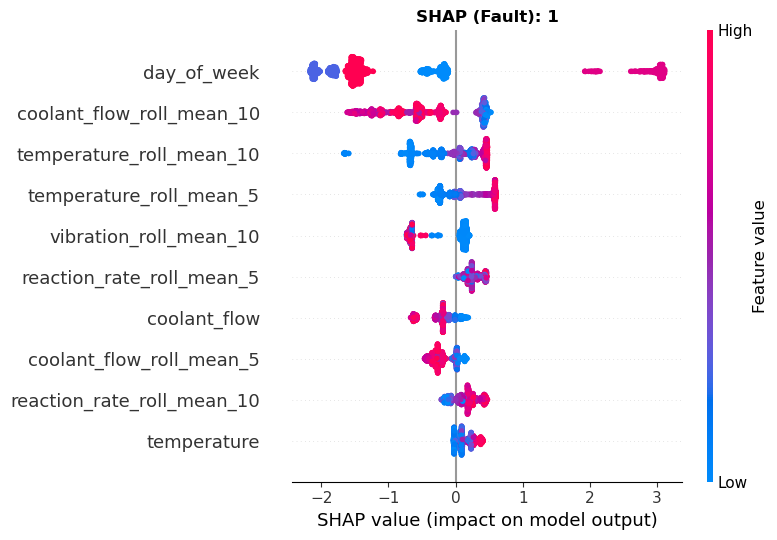

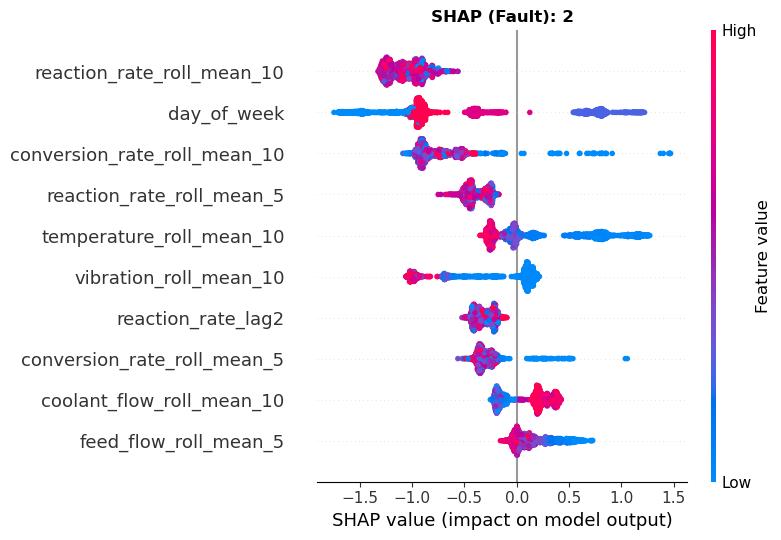

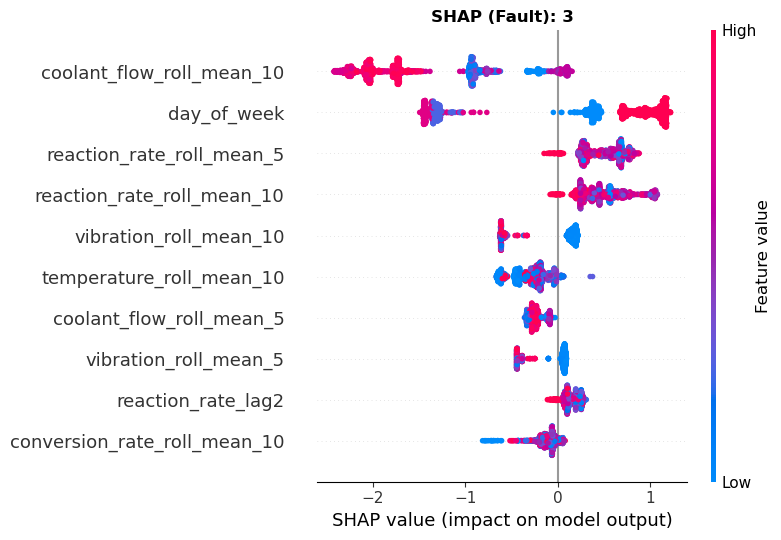

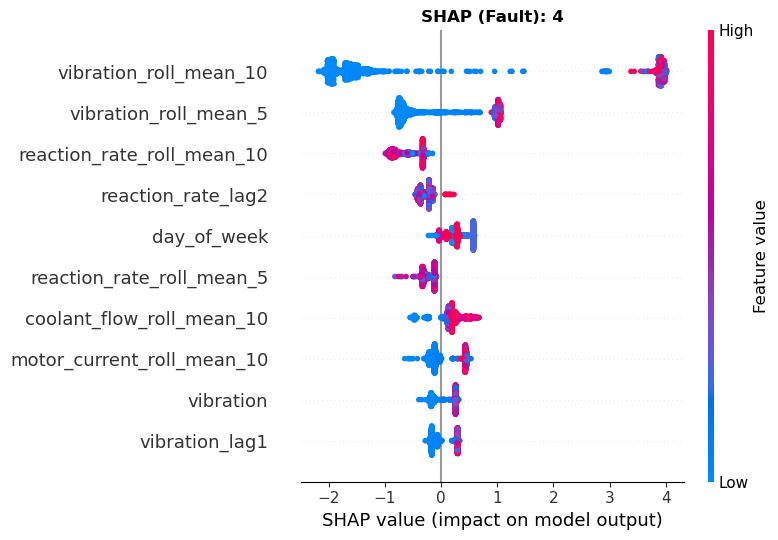

In [137]:
n_classes_plot = min(N_CLS_TUNE, 6)

shap_vals_mc = np.array(shap_vals_mc)

for k in range(n_classes_plot):
    
    if k < len(le_tune_mc.classes_):
        class_name = CLASS_NAMES_MC[le_tune_mc.classes_[k]]
    else:
        class_name = f"Class {k}"
    
    plt.figure(figsize=(7, 5))
    
    shap.summary_plot(
        shap_vals_mc[:, :, k], 
        X_shap_mc,
        feature_names=feature_cols_mc,
        max_display=10,
        show=False
    )
    
    plt.title(f"SHAP (Fault): {class_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    plt.savefig(f"shap_class_{k}.png", dpi=150, bbox_inches='tight')
    
    plt.show()


  Fault class 0: 1  (test sample index 0)


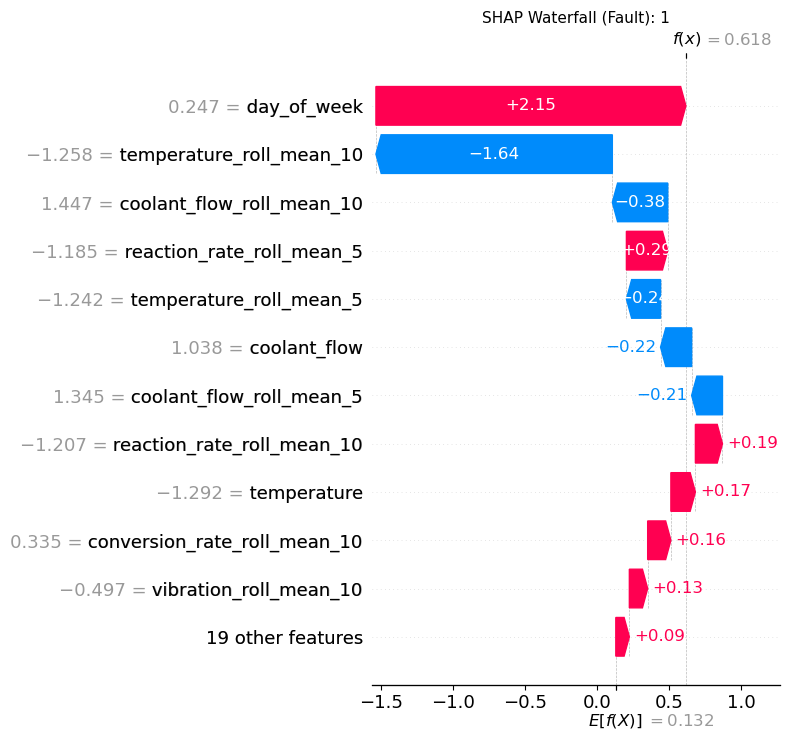

  Class 1 (2): correct samples outside SHAP window — skipping
  Class 2 (3): correct samples outside SHAP window — skipping

  Fault class 3: 4  (test sample index 1230)


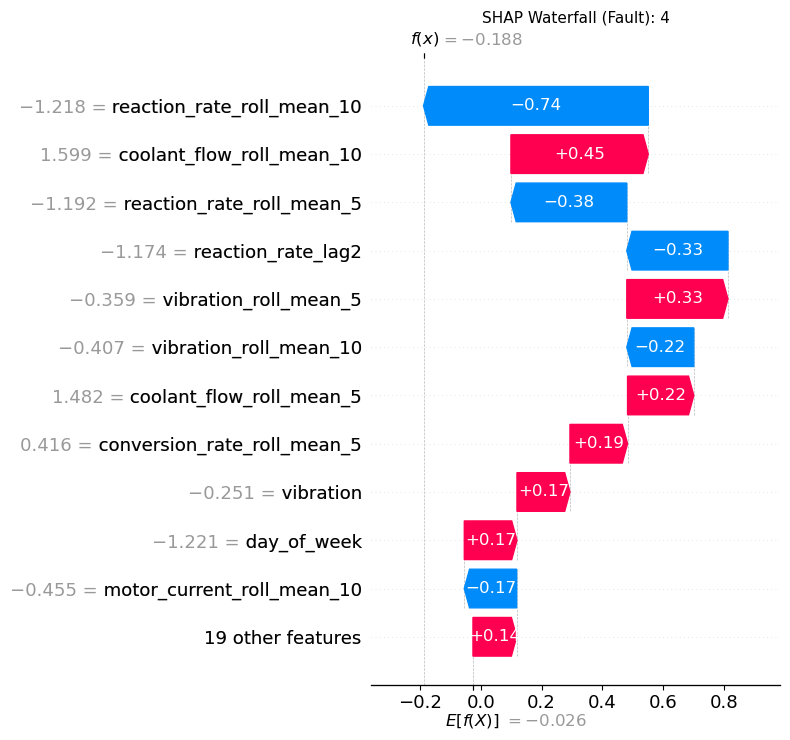

In [148]:
label_to_classname = {k: CLASS_NAMES_MC[le_tune_mc.classes_[k]]
                      for k in range(N_CLS_TUNE)}

y_pred_mc_tuned_e_full = xgb_mc_best.predict(X_mc_te)

for k in range(N_CLS_TUNE):
    true_enc   = le_tune_mc.transform(y_mc_te)
    correct_idx = np.where((true_enc == k) & (y_pred_mc_tuned_e_full == k))[0]

    if len(correct_idx) == 0:
        print(f"  Class {k} ({label_to_classname[k]}): no correct predictions , skipping")
        continue

    shap_idx_candidates = correct_idx[correct_idx < MAX_SHAP_MC]
    if len(shap_idx_candidates) == 0:
        print(f"  Class {k} ({label_to_classname[k]}): correct samples outside SHAP window , skipping")
        continue

    idx = shap_idx_candidates[0]
    base_val = (explainer_mc.expected_value[k]
                if isinstance(explainer_mc.expected_value, (list, np.ndarray))
                else explainer_mc.expected_value)

    exp = shap.Explanation(
        values        = shap_vals_mc[:,:,k][idx],
        base_values   = base_val,
        data          = X_shap_mc[idx],
        feature_names = feature_cols_mc
    )

    print(f"\n  Fault class {k}: {label_to_classname[k]}  (test sample index {idx})")
    shap.waterfall_plot(exp, show=False, max_display=12)
    plt.title(f"SHAP Waterfall (Fault): {label_to_classname[k]}", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"22_shap_waterfall_class{k}.png", dpi=150, bbox_inches='tight')
    plt.show()


The per-class plots are where this analysis becomes most useful in practice. If one fault type is consistently flagged by rolling-mean-temperature features and another by rolling-std-vibration, that maps directly to which sensors to watch for early warning of each fault type. This kind of insight can't be extracted from a confusion matrix.

In [140]:
test_mc_c = test_mc.copy()
test_mc_c['pred_rf']  = y_pred_rf_mc
test_mc_c['pred_xgb'] = y_pred_xgb_mc
test_mc_c['pred_lgb'] = y_pred_lgb_mc

if 'reactor_id' in test_mc_c.columns:
    for model, col in [('RF', 'pred_rf'), ('XGB', 'pred_xgb'), ('LGB', 'pred_lgb')]:
        acc = test_mc_c.groupby('reactor_id').apply(
            lambda x: (x['fault_mc'] == x[col]).mean()
        )
        print(f"\nReactor-wise accuracy ({model}):")
        print(acc)


Reactor-wise accuracy (RF):
reactor_id
A_R2    0.861936
A_R3    0.606422
B_R1    0.691558
B_R2    0.611898
B_R3    0.984072
dtype: float64

Reactor-wise accuracy (XGB):
reactor_id
A_R2    0.749725
A_R3    0.334862
B_R1    0.961039
B_R2    0.626062
B_R3    0.984072
dtype: float64

Reactor-wise accuracy (LGB):
reactor_id
A_R2    0.804730
A_R3    0.071560
B_R1    0.970779
B_R2    0.560907
B_R3    0.982687
dtype: float64


## Final Model Summary

The table below brings together the key metrics from every model trained in this notebook, organised by task. For classification tasks the relevant metrics are weighted F1, macro F1, and balanced accuracy , accuracy alone is misleading with imbalanced classes. For regression the relevant metrics are MAE and R².

In [142]:
summary_rows = []

summary_rows.append({
    'Task': 'Binary Fault Detection',
    'Model': 'XGBoost (default)',
    'Accuracy': round(accuracy_score(y_test, y_pred_bin), 4),
    'Weighted F1': round(f1_score(y_test, y_pred_bin, average='weighted'), 4),
    'Macro F1': ',', 'Bal-Acc': ',', 'MAE': ',', 'R²': ','
})
summary_rows.append({
    'Task': 'Binary Fault Detection',
    'Model': 'XGBoost (tuned)',
    'Accuracy': round(accuracy_score(y_test, y_pred_best), 4),
    'Weighted F1': round(f1_score(y_test, y_pred_best, average='weighted'), 4),
    'Macro F1': ',', 'Bal-Acc': ',', 'MAE': ',', 'R²': ','
})
summary_rows.append({
    'Task': 'Binary Fault Detection',
    'Model': 'IsolationForest (unsupervised)',
    'Accuracy': round(accuracy_score(y_test, y_pred_iso), 4),
    'Weighted F1': round(f1_score(y_test, y_pred_iso, average='weighted', zero_division=0), 4),
    'Macro F1': ',', 'Bal-Acc': ',', 'MAE': ',', 'R²': ','
})

for label, preds in [
    ('Random Forest (default)',  y_pred_rf_mc),
    ('XGBoost (default)',        y_pred_xgb_mc),
    ('LightGBM (default)',       y_pred_lgb_mc),
    ('XGBoost (tuned)',          y_pred_mc_tuned),
]:
    summary_rows.append({
        'Task'       : 'Fault Classification',
        'Model'      : label,
        'Accuracy'   : round(accuracy_score(y_mc_te, preds), 4),
        'Weighted F1': round(f1_score(y_mc_te, preds, average='weighted', zero_division=0), 4),
        'Macro F1'   : round(f1_score(y_mc_te, preds, average='macro',    zero_division=0), 4),
        'Bal-Acc'    : round(balanced_accuracy_score(y_mc_te, preds), 4),
        'MAE': ',', 'R²': ','
    })

for label, preds in [('Random Forest', y_rf_reg), ('XGBoost', y_xgb_reg)]:
    summary_rows.append({
        'Task'       : 'Efficiency Loss Regression',
        'Model'      : label,
        'Accuracy'   : ',', 'Weighted F1': ',', 'Macro F1': ',', 'Bal-Acc': ',',
        'MAE'        : round(mean_absolute_error(y_reg_te, preds), 4),
        'R²'         : round(r2_score(y_reg_te, preds), 4),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Task,Model,Accuracy,Weighted F1,Macro F1,Bal-Acc,MAE,R²
0,Binary Fault Detection,XGBoost (default),0.9953,0.9953,—,—,—,—
1,Binary Fault Detection,XGBoost (tuned),0.996,0.996,—,—,—,—
2,Binary Fault Detection,IsolationForest (unsupervised),0.9792,0.9771,—,—,—,—
3,Fault Classification,Random Forest (default),0.8135,0.8323,0.749,0.8187,—,—
4,Fault Classification,XGBoost (default),0.7313,0.7757,0.7162,0.7824,—,—
5,Fault Classification,LightGBM (default),0.6896,0.7087,0.6395,0.7478,—,—
6,Fault Classification,XGBoost (tuned),0.7528,0.7896,0.7241,0.7919,—,—
7,Efficiency Loss Regression,Random Forest,—,—,—,—,0.092,0.9561
8,Efficiency Loss Regression,XGBoost,—,—,—,—,0.1075,0.9529


## Conclusion

This project worked through three progressively harder ML tasks on the same chemical process dataset, using the same feature engineering pipeline throughout.

Binary fault detection using a tuned XGBoost model achieved strong performance across all reactors, and the SHAP analysis confirmed the model is responding to physically meaningful sensor patterns specifically, sustained trends in rolling statistics rather than instantaneous spikes.

The regression model for efficiency loss prediction performed well on the majority of operating conditions, with some spread at the extremes indicating that very high efficiency losses are harder to predict precisely, likely because they correspond to rare or unusual fault combinations.

Fault type classification remained the most difficult task, largely because some fault types appear infrequently even in the fault-only subset. The SHAP per-class analysis is the most practically useful output here: even where classification accuracy is imperfect, the feature attributions tell process engineers which sensors to monitor for each fault type, which is actionable regardless of whether the model is deployed in production.

The most important methodological decisions in this notebook, time-based splits, SMOTE inside CV folds, separate scalers per task, shuffled-label validation are each grounded in a specific risk of data leakage or evaluation bias. Getting these right matters more than model choice for any real deployment.